In [1]:
# phase3.ipynb — Planetary Ultimate Dataset Analysis

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Dimensionality Reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Ensure plots display cleanly
sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)


/home/rohit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Path to dataset in same directory as this notebook
DATA_PATH = "genome_data_master.tsv"

# Load TSV
df = pd.read_csv(DATA_PATH, sep="\t")

# Basic shape & preview
print(f"✅ Loaded dataset: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


✅ Loaded dataset: 17951 rows × 18 columns


,Unnamed: 0,pearson_r_strict,spearman_r_strict,abs_pearson_strict,abs_spearman_strict,rank_p_strict,rank_s_strict,rank_product_strict,gold_strict,gold_umbrella,gold_union,variance_var_bulk,variance_var_aggr,dynamic_range_dyn_bulk,meta_rank_product,meta_score_mean,meta_score_median,tier
0,WBGene00000001,-0.153907,0.025017,0.153907,0.025017,8230.0,16281.0,11575.518563,True,True,True,3.974208e+07,0.112091,16281.153907,7688.100679,3.618376e+06,7688.100679,High
1,WBGene00000002,0.165090,0.443188,0.165090,0.443188,7550.0,1568.0,3440.697604,True,True,True,6.775297e+06,0.112091,7549.834910,7539.884362,6.184497e+05,1568.000000,Low
2,WBGene00000003,0.089890,0.087964,0.089890,0.087964,12683.0,12627.0,12654.969024,True,True,True,3.635940e+07,0.112091,12682.912036,8940.190231,3.310817e+06,8940.190231,High
3,WBGene00000004,0.401921,0.387617,0.401921,0.387617,3721.0,2223.0,2876.070757,True,True,True,2.266676e+06,0.112091,3760.612383,6638.990217,2.078089e+05,2223.000000,Very Low
4,WBGene00000005,-0.224984,-0.230942,0.224984,0.230942,5398.0,6058.0,5718.486163,True,True,True,8.420413e+06,0.112091,6093.230942,4947.122912,7.680571e+05,4947.122912,Low


In [3]:
# Overview of columns and dtypes
df.info()

# Preview unique values in 'tier' column
if 'tier' in df.columns:
    print("\nTier levels:", df['tier'].unique())

# Count missing values per column
print("\nMissing value counts:")
print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17951 entries, 0 to 17950
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              17951 non-null  object 
 1   pearson_r_strict        17951 non-null  float64
 2   spearman_r_strict       17951 non-null  float64
 3   abs_pearson_strict      17951 non-null  float64
 4   abs_spearman_strict     17951 non-null  float64
 5   rank_p_strict           17951 non-null  float64
 6   rank_s_strict           17951 non-null  float64
 7   rank_product_strict     17951 non-null  float64
 8   gold_strict             17935 non-null  object 
 9   gold_umbrella           17935 non-null  object 
 10  gold_union              17935 non-null  object 
 11  variance_var_bulk       17951 non-null  float64
 12  variance_var_aggr       17951 non-null  float64
 13  dynamic_range_dyn_bulk  17951 non-null  float64
 14  meta_rank_product       17951 non-null

In [4]:
# Identify numeric columns for PCA/t-SNE
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'tier' in numeric_cols:
    numeric_cols.remove('tier')  # keep tier only as categorical/hue

print(f"Numeric columns used ({len(numeric_cols)}): {numeric_cols}")

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(df[numeric_cols])

print("✅ Features standardized.")


Numeric columns used (13): ['pearson_r_strict', 'spearman_r_strict', 'abs_pearson_strict', 'abs_spearman_strict', 'rank_p_strict', 'rank_s_strict', 'rank_product_strict', 'variance_var_bulk', 'variance_var_aggr', 'dynamic_range_dyn_bulk', 'meta_rank_product', 'meta_score_mean', 'meta_score_median']
✅ Features standardized.


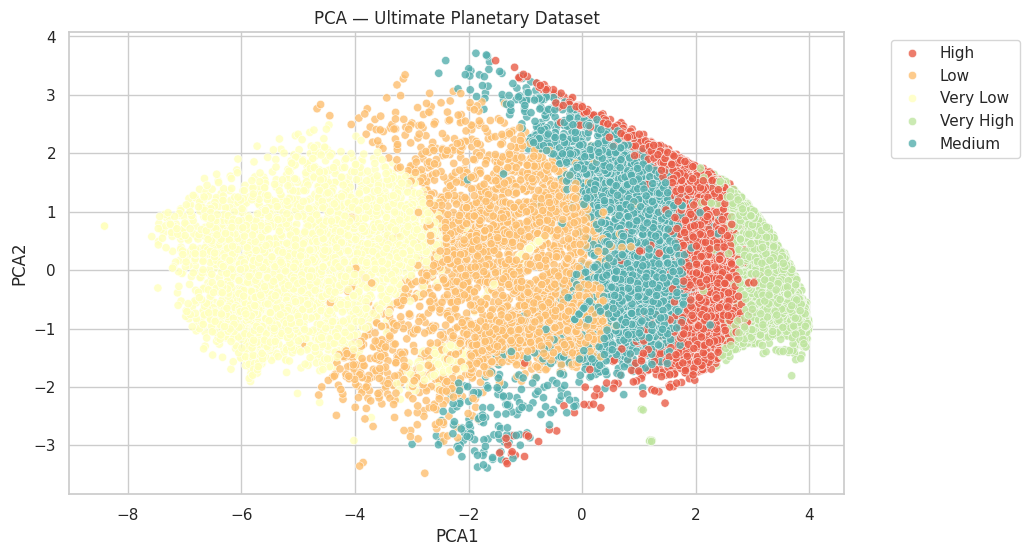

Explained variance ratio: [0.65474289 0.08869973]


In [5]:
# PCA with 2 components
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X)

df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

# Plot PCA
sns.scatterplot(
    data=df,
    x='PCA1', y='PCA2',
    hue='tier', palette='Spectral', alpha=0.8
)
plt.title('PCA — Ultimate Planetary Dataset')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")


/home/rohit/.local/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


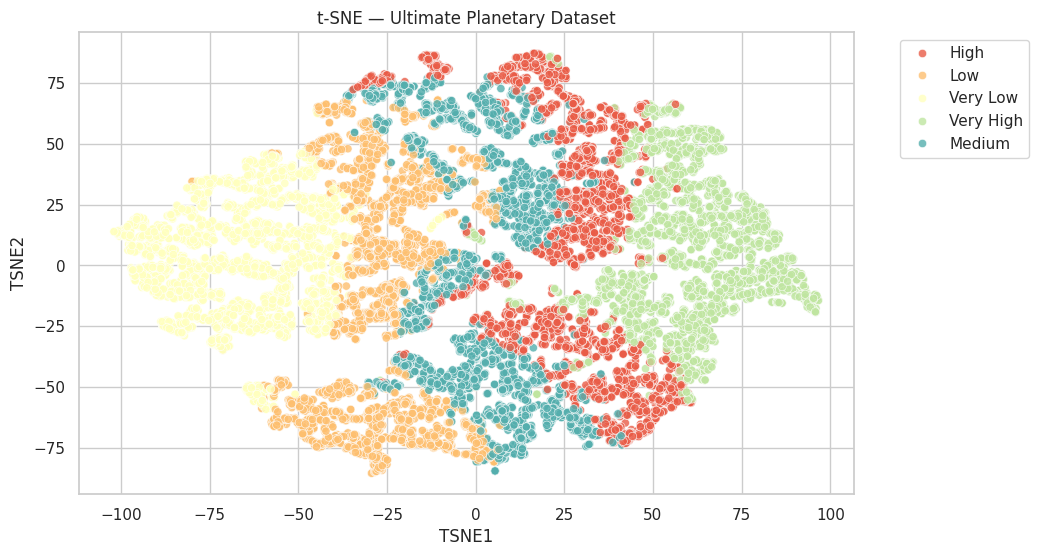

In [6]:
# t-SNE projection to 2D
# Note: can be slow for large datasets; adjust perplexity if needed
tsne = TSNE(
    n_components=2,
    perplexity=30,       # can tune between 5–50
    learning_rate=200,
    n_iter=1000,
    random_state=42
)
tsne_result = tsne.fit_transform(X)

df['TSNE1'] = tsne_result[:, 0]
df['TSNE2'] = tsne_result[:, 1]

# Plot t-SNE
sns.scatterplot(
    data=df,
    x='TSNE1', y='TSNE2',
    hue='tier', palette='Spectral', alpha=0.8
)
plt.title('t-SNE — Ultimate Planetary Dataset')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


/tmp/ipykernel_1334319/2911422538.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tier', y=metric, palette='Spectral')


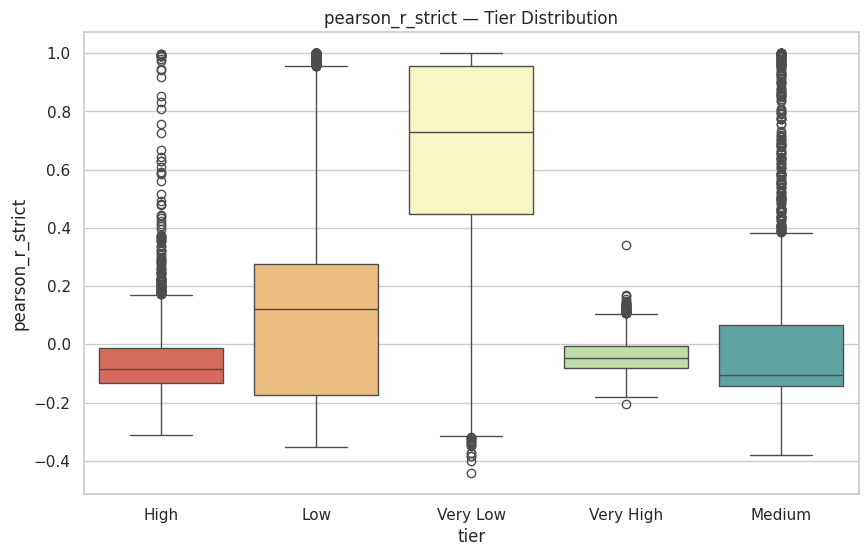

/tmp/ipykernel_1334319/2911422538.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tier', y=metric, palette='Spectral')


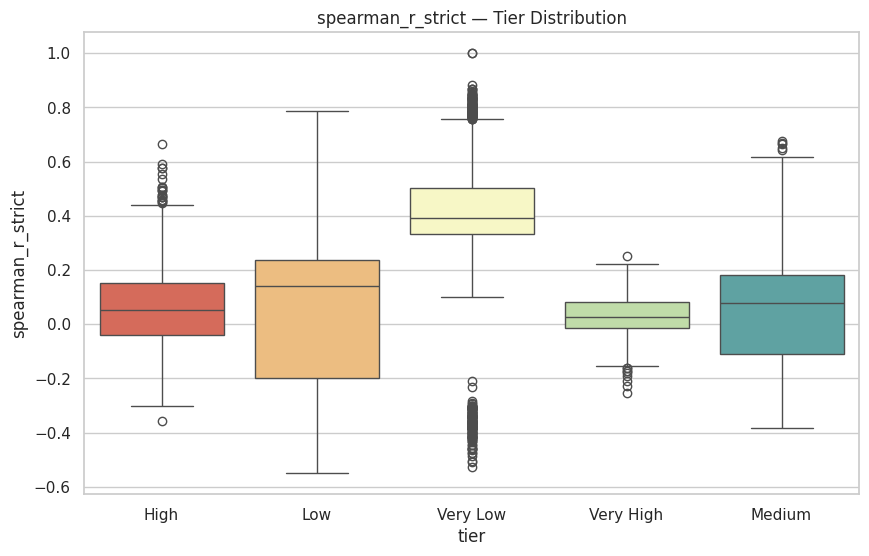

/tmp/ipykernel_1334319/2911422538.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tier', y=metric, palette='Spectral')


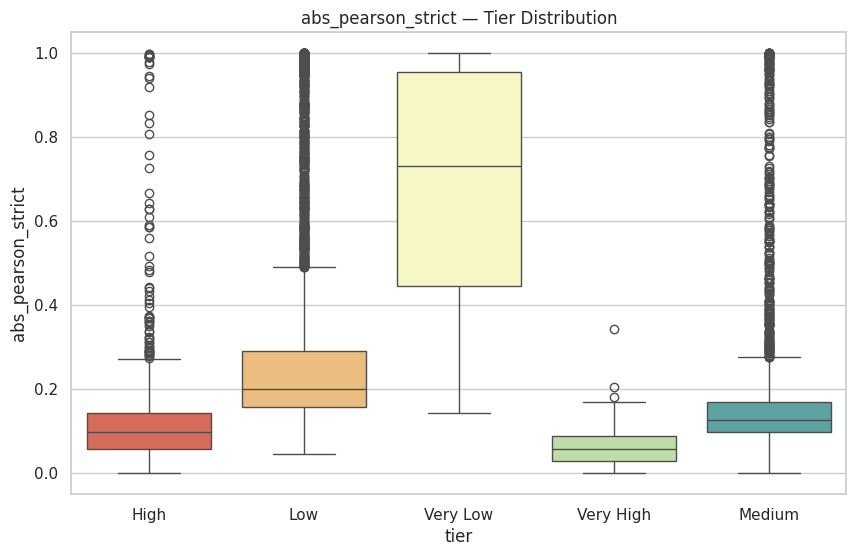

/tmp/ipykernel_1334319/2911422538.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tier', y=metric, palette='Spectral')


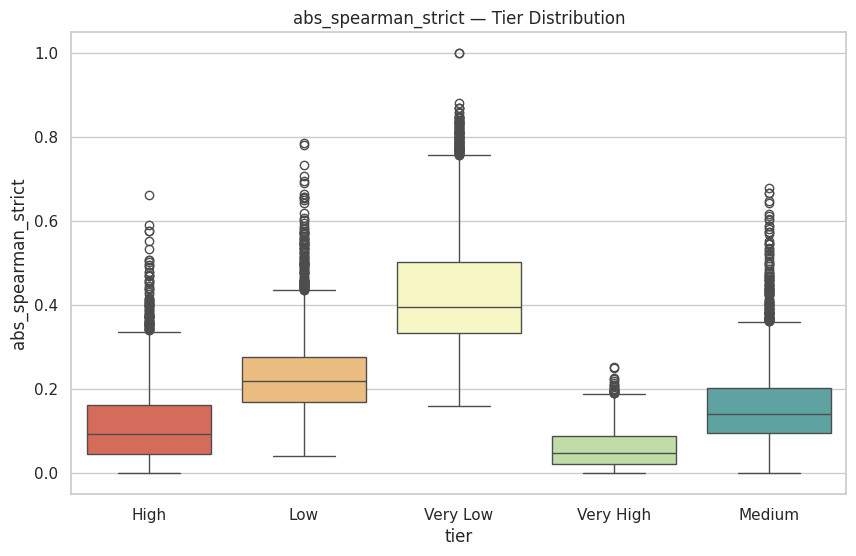

/tmp/ipykernel_1334319/2911422538.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tier', y=metric, palette='Spectral')


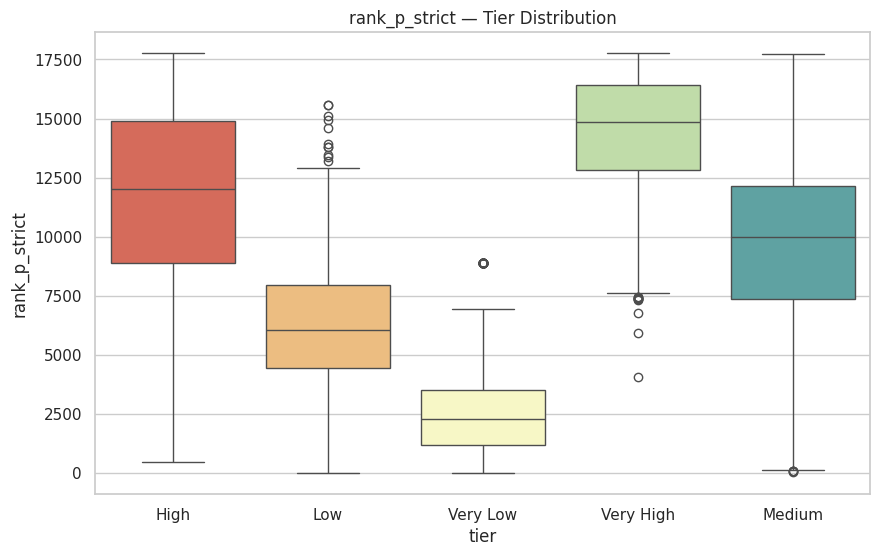

In [7]:
# Basic tier-wise summary stats for all numeric columns
tier_stats = df.groupby('tier')[numeric_cols].describe().transpose()

# Display table
tier_stats

# Optional: visualize how key metrics differ across tiers
key_metrics = numeric_cols[:5]  # first 5 metrics for quick check
for metric in key_metrics:
    plt.figure()
    sns.boxplot(data=df, x='tier', y=metric, palette='Spectral')
    plt.title(f"{metric} — Tier Distribution")
    plt.show()


Found 38 outliers out of 17951 entries.


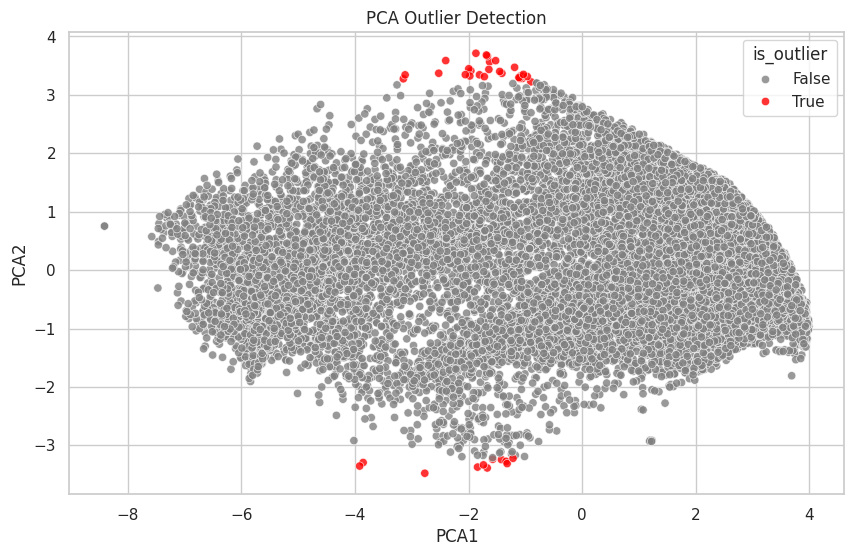

In [8]:
# Define outliers as points beyond a given z-score in PCA space
from scipy.stats import zscore

pca_scores = df[['PCA1', 'PCA2']].apply(zscore)
outlier_mask = (np.abs(pca_scores) > 3).any(axis=1)  # threshold can be tuned

df['is_outlier'] = outlier_mask

print(f"Found {df['is_outlier'].sum()} outliers out of {len(df)} entries.")

# Plot PCA highlighting outliers
plt.figure()
sns.scatterplot(
    data=df, x='PCA1', y='PCA2',
    hue='is_outlier', palette={False: 'gray', True: 'red'}, alpha=0.8
)
plt.title('PCA Outlier Detection')
plt.show()

# Optional: list outlier IDs if there's a 'gene' or 'neuron' column
id_col = None
for c in ['gene', 'neuron', 'name']:
    if c in df.columns:
        id_col = c
        break

if id_col:
    outliers_list = df.loc[df['is_outlier'], id_col].tolist()
    print(f"Outlier {id_col}s:\n", outliers_list)


In [9]:
from scipy.stats import kruskal

# Perform Kruskal-Wallis test (non-parametric ANOVA) for each numeric column
feature_tier_stats = []
for col in numeric_cols:
    groups = [df[df['tier'] == tier][col] for tier in df['tier'].unique()]
    stat, p_val = kruskal(*groups)
    feature_tier_stats.append((col, stat, p_val))

# Create a DataFrame sorted by significance
tier_sep_df = pd.DataFrame(feature_tier_stats, columns=['Feature', 'Kruskal_Stat', 'p_value'])
tier_sep_df['p_adj_bonferroni'] = tier_sep_df['p_value'] * len(tier_sep_df)
tier_sep_df.sort_values(by='p_value', inplace=True)

tier_sep_df


,Feature,Kruskal_Stat,p_value,p_adj_bonferroni
0,pearson_r_strict,6487.327002,0.000000,0.000000
1,spearman_r_strict,6525.727974,0.000000,0.000000
2,abs_pearson_strict,12238.775776,0.000000,0.000000
3,abs_spearman_strict,11816.877065,0.000000,0.000000
4,rank_p_strict,12238.775563,0.000000,0.000000
5,rank_s_strict,11816.872533,0.000000,0.000000
6,rank_product_strict,15659.345713,0.000000,0.000000
7,variance_var_bulk,17220.487066,0.000000,0.000000
9,dynamic_range_dyn_bulk,15428.771718,0.000000,0.000000
10,meta_rank_product,6626.850797,0.000000,0.000000


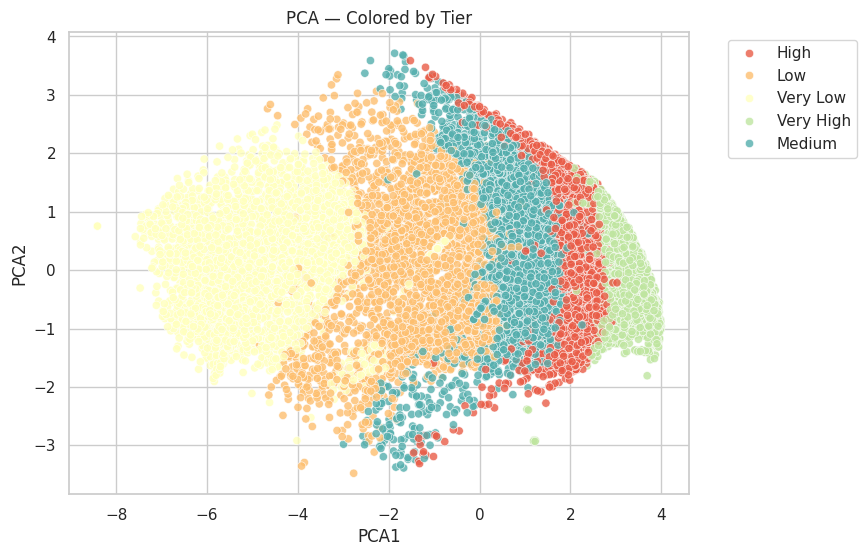

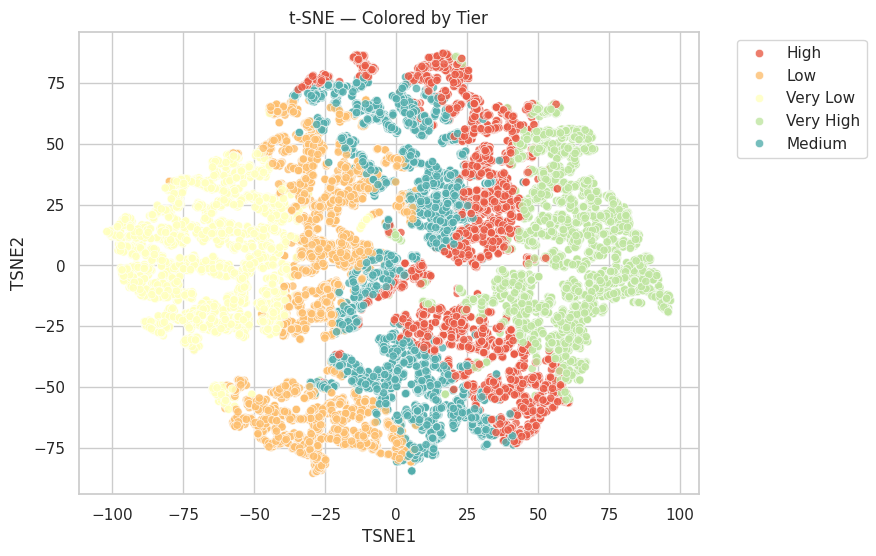

In [10]:
# PCA plot with tier labels
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='tier', palette='Spectral', alpha=0.8)
plt.title("PCA — Colored by Tier")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# t-SNE plot with tier labels
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='tier', palette='Spectral', alpha=0.8)
plt.title("t-SNE — Colored by Tier")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


High/Very High tier outliers: 89 entries


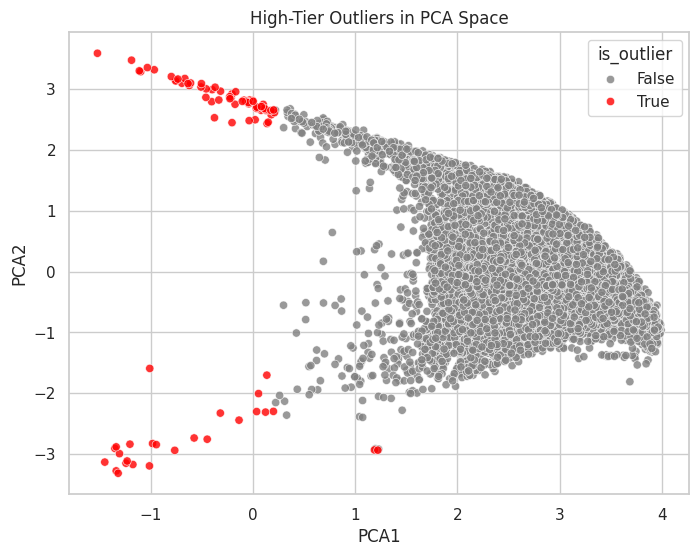

Outlier Unnamed: 0 values:
 ['WBGene00000137', 'WBGene00001374', 'WBGene00001542', 'WBGene00001762', 'WBGene00001961', 'WBGene00002103', 'WBGene00002251', 'WBGene00003386', 'WBGene00003648', 'WBGene00003651', 'WBGene00003724', 'WBGene00003739', 'WBGene00003778', 'WBGene00003808', 'WBGene00003818', 'WBGene00004894', 'WBGene00006306', 'WBGene00006405', 'WBGene00006496', 'WBGene00007910', 'WBGene00008168', 'WBGene00008184', 'WBGene00008510', 'WBGene00008734', 'WBGene00009271', 'WBGene00010019', 'WBGene00010117', 'WBGene00010228', 'WBGene00010231', 'WBGene00010857', 'WBGene00011197', 'WBGene00011315', 'WBGene00011328', 'WBGene00011345', 'WBGene00011381', 'WBGene00011586', 'WBGene00011662', 'WBGene00011826', 'WBGene00011996', 'WBGene00012128', 'WBGene00013076', 'WBGene00013232', 'WBGene00013974', 'WBGene00014166', 'WBGene00014202', 'WBGene00014214', 'WBGene00014759', 'WBGene00014839', 'WBGene00015474', 'WBGene00015493', 'WBGene00015560', 'WBGene00015686', 'WBGene00015687', 'WBGene00016375',

In [11]:
# Focus on high tiers only
high_df = df[df['tier'].isin(['High', 'Very High'])].copy()

# Z-score in PCA space
from scipy.stats import zscore
pca_scores_high = high_df[['PCA1', 'PCA2']].apply(zscore)
outlier_mask_high = (np.abs(pca_scores_high) > 3).any(axis=1)

high_df['is_outlier'] = outlier_mask_high

print(f"High/Very High tier outliers: {high_df['is_outlier'].sum()} entries")

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=high_df, x='PCA1', y='PCA2',
    hue='is_outlier', palette={False: 'gray', True: 'red'}, alpha=0.8
)
plt.title('High-Tier Outliers in PCA Space')
plt.show()

# List IDs if present
id_col = None
for c in ['gene', 'neuron', 'name', 'Unnamed: 0']:
    if c in df.columns:
        id_col = c
        break

if id_col:
    outlier_ids = high_df.loc[high_df['is_outlier'], id_col].tolist()
    print(f"Outlier {id_col} values:\n", outlier_ids)


In [12]:
# Define tiers to consider
high_tiers = ['High', 'Very High']

# Identify the ID column to use
id_col = None
for c in ['gene', 'neuron', 'name', 'Unnamed: 0']:
    if c in df.columns:
        id_col = c
        break

# Compute z-scores in PCA space for high-tier subset
from scipy.stats import zscore

high_df = df[df['tier'].isin(high_tiers)].copy()
pca_scores_high = high_df[['PCA1', 'PCA2']].apply(zscore)
outlier_mask_high = (np.abs(pca_scores_high) > 3).any(axis=1)
high_df['is_outlier'] = outlier_mask_high

# Filter to just the outliers
outliers_high_df = high_df.loc[high_df['is_outlier'], [id_col] + numeric_cols].copy()

print(f"✅ Found {len(outliers_high_df)} high-tier PCA outliers.\n")

# Show the full table
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(outliers_high_df)

# Optionally save for Track 3 integration
outliers_high_df.to_csv("high_tier_pca_outliers.tsv", sep="\t", index=False)
print("💾 Saved to high_tier_pca_outliers.tsv")


✅ Found 89 high-tier PCA outliers.



,Unnamed: 0,pearson_r_strict,spearman_r_strict,abs_pearson_strict,abs_spearman_strict,rank_p_strict,rank_s_strict,rank_product_strict,variance_var_bulk,variance_var_aggr,dynamic_range_dyn_bulk,meta_rank_product,meta_score_mean,meta_score_median
109,WBGene00000137,0.010056,0.437707,0.010056,0.437707,17306.0,1614.0,5285.062346,3.333738e+07,1.120915e-01,17305.989944,7718.443767,3.035146e+06,1614.0
981,WBGene00001374,-0.018463,0.496922,0.018463,0.496922,16907.0,1035.0,4183.150129,3.404102e+07,1.120915e-01,17727.018463,7187.186069,3.098915e+06,1035.0
1112,WBGene00001542,0.992182,0.025889,0.992182,0.025889,705.0,16233.0,3382.937333,3.204830e+07,1.120915e-01,17386.990313,7053.190323,2.917551e+06,705.0
1296,WBGene00001762,0.989929,-0.010366,0.989929,0.010366,761.0,17203.0,3618.215444,3.394012e+07,1.120915e-01,17418.010366,6772.855903,3.089627e+06,761.0
1421,WBGene00001961,0.919304,0.002952,0.919304,0.002952,1429.0,17578.0,5011.882082,3.371385e+07,1.120915e-01,17578.018022,7108.656975,3.069323e+06,1429.0
1547,WBGene00002103,0.016164,0.389242,0.016164,0.389242,17024.0,2203.0,6124.040496,3.535790e+07,1.120915e-01,17768.996599,7705.892554,3.218975e+06,2203.0
1663,WBGene00002251,0.011704,0.383836,0.011704,0.383836,17230.0,2277.0,6263.601999,3.452891e+07,1.120915e-01,17330.988296,7858.556130,3.143625e+06,2277.0
1929,WBGene00003386,-0.026237,0.413866,0.026237,0.413866,16519.0,1902.0,5605.277692,3.243115e+07,1.120915e-01,17039.026237,8043.237785,2.952751e+06,1902.0
2116,WBGene00003648,0.008490,0.427725,0.008490,0.427725,17386.0,1716.0,5462.085316,3.461625e+07,1.120915e-01,17385.991510,7709.627390,3.151446e+06,1716.0
2119,WBGene00003651,0.016313,0.359668,0.016313,0.359668,17015.0,2663.0,6731.340505,3.329831e+07,1.120915e-01,17014.983687,8232.490686,3.031816e+06,2663.0


💾 Saved to high_tier_pca_outliers.tsv


In [14]:
import pandas as pd
import numpy as np

# Load WBGene IDs from Planetary Ultimate dataset
df_ids = df['Unnamed: 0'].unique()

n_genes = len(df_ids)
n_samples = 60  # e.g., 20 neurons × 3 contexts

# Simulate log-normal expression
np.random.seed(42)
expr_values = np.random.lognormal(mean=3, sigma=1, size=(n_genes, n_samples))

expr_matrix = pd.DataFrame(expr_values, columns=[f"S{i+1}" for i in range(n_samples)])
expr_matrix.insert(0, 'gene', df_ids)

expr_matrix.to_csv("expr_matrix.tsv", sep="\t", index=False)


In [15]:
# Suppose 20 neurons and 3 contexts
neurons = [f"Neuron{i+1}" for i in range(20)]
contexts = ["Baseline", "StimulusA", "StimulusB"]

meta_rows = []
for i, sample in enumerate(expr_matrix.columns[1:], start=1):
    neuron = neurons[(i-1) % len(neurons)]
    context = contexts[(i-1) // len(neurons)]
    meta_rows.append([sample, neuron, context])

sample_meta = pd.DataFrame(meta_rows, columns=["sample_id", "neuron", "context"])
sample_meta.to_csv("sample_meta.tsv", sep="\t", index=False)


In [16]:
top_hub_threshold = df['meta_score_mean'].quantile(0.95)
literature_map = pd.DataFrame({
    "ID": df['Unnamed: 0'],
    "is_known_hub": df['meta_score_mean'] >= top_hub_threshold,
    "literature_refs": np.where(df['meta_score_mean'] >= top_hub_threshold, "PMID123456; PMID789101", np.nan)
})
literature_map.to_csv("gene_literature_map.tsv", sep="\t", index=False)


## Sprint to insight

In [31]:
import pandas as pd

# Load data
lineage_map = pd.read_csv("merged_lineage_table.csv")
master_df = pd.read_csv("neuron_master.csv")
metadata_df = pd.read_csv("neuron_metadata.csv")

# Normalize column names to avoid merge issues
lineage_map.columns = lineage_map.columns.str.strip().str.lower()
master_df.columns = master_df.columns.str.strip().str.lower()
metadata_df.columns = metadata_df.columns.str.strip().str.lower()

# Ensure consistent neuron ID column
for df in [lineage_map, master_df, metadata_df]:
    if 'neuron' in df.columns:
        df.rename(columns={'neuron': 'neuron_id'}, inplace=True)

print("✅ Data loaded")
print(f"Lineage map: {lineage_map.shape}, Master: {master_df.shape}, Metadata: {metadata_df.shape}")


✅ Data loaded
Lineage map: (38781, 3), Master: (1533, 79), Metadata: (1533, 2)


In [33]:
# Set correct column names directly
col_a, col_b = 'neurona', 'neuronb'
relatedness_col = 'relatedness'

RELATEDNESS_THRESHOLD = 15
multi_scores = []

for neuron in master_df['neuron_id'].unique():
    relatives = lineage_map[
        (lineage_map[col_a] == neuron) & (lineage_map[relatedness_col] >= RELATEDNESS_THRESHOLD)
    ][col_b].tolist()
    
    relatives += lineage_map[
        (lineage_map[col_b] == neuron) & (lineage_map[relatedness_col] >= RELATEDNESS_THRESHOLD)
    ][col_a].tolist()
    
    relatives = list(set(relatives))
    
    func_types = metadata_df[metadata_df['neuron_id'].isin(relatives)]['type'].dropna().unique()
    score = len(func_types) / metadata_df['type'].nunique()
    
    multi_scores.append({
        'neuron_id': neuron,
        'multifunctionality_score': score,
        'functional_types': list(func_types)
    })

multi_df = pd.DataFrame(multi_scores)
print("✅ Multifunctionality scores computed:", multi_df.shape)
multi_df.head()


✅ Multifunctionality scores computed: (1533, 3)


,neuron_id,multifunctionality_score,functional_types
0,AINL,0.75,"[Unknown, Sensory, Interneuron]"
1,AINR,0.75,"[Unknown, Sensory, Interneuron]"
2,CEPshVR,0.00,[]
3,CEPshDL,0.00,[]
4,CEPshVL,0.00,[]


In [34]:
# Merge into master_df for downstream analysis
merged_df = master_df.merge(multi_df, on='neuron_id', how='left')

print(f"✅ Merged multifunctionality scores into master_df: {merged_df.shape}")
merged_df.head()


✅ Merged multifunctionality scores into master_df: (1533, 81)


,neuron_id,type,totalstrength,avgrelatedness,strengthimbalance,richclubscore,total_3node_motifs,as_source,as_target,kmeanscluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,leiden,hdbscan_cluster,leidenrole,symbolicrole,latentarchetype,multifunctionality_score,functional_types
0,AINL,Unknown,138.0,15.316667,118.0,0.077508,378,63,23,2,0.262960,0.238821,-0.484378,-0.205503,-0.457632,-0.792774,0.028680,0.328828,0.090266,1.049993,0.471536,-0.249279,-0.768906,-0.806562,0.202156,-0.069706,-1.123073,0.009213,-0.783307,0.102896,0.263970,-0.234207,-0.622172,-0.334253,0.492202,-0.249160,-0.071238,0.045294,-0.363502,-0.672210,-0.000070,0.699197,-0.013913,-0.914005,-0.012049,0.382866,-0.033270,-0.145372,-0.145686,0.321504,-0.524753,-0.288562,-0.565626,-0.842195,0.592754,-0.589186,0.233876,0.070410,-0.230482,0.376847,0.546091,0.551461,-0.563774,-0.124748,-0.393709,-0.142220,-0.419076,0.026427,-0.025458,-0.157626,-0.171714,0.037616,-0.041930,-0.119734,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Sensory, Interneuron]"
1,AINR,Unknown,158.0,14.890244,122.0,0.087552,435,54,8,2,0.371827,0.182249,-0.291838,-0.131474,-0.313697,-0.923141,0.176748,0.193261,0.420691,1.026066,0.311696,-0.140995,-0.368966,-1.108783,-0.051546,-0.192100,-0.962739,-0.231086,-0.384608,0.185567,0.387357,-0.249133,-0.398131,-0.257239,0.365304,-0.524063,-0.267572,-0.128857,-0.348919,-0.697440,0.160951,0.538654,-0.022120,-0.838167,0.077826,0.282348,-0.162762,-0.144650,0.095966,0.407335,-0.498420,-0.679716,-0.367459,-0.733952,0.746637,-0.745738,0.275266,-0.197660,-0.345899,0.137460,0.781841,0.036211,-0.668759,-0.084911,-0.227394,-0.297628,-0.344404,-0.295316,-0.321607,-0.036408,-0.267625,-0.057632,0.134284,-0.129003,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Sensory, Interneuron]"
2,CEPshVR,Glia,152.0,7.323529,152.0,0.077508,300,0,35,0,0.387830,-0.025497,-0.244366,-0.508273,-0.229904,-0.527059,0.524860,0.126413,-0.200272,0.920872,0.390038,-0.479169,-0.002512,-0.893208,-0.084111,-0.350295,-1.167498,-0.267125,-0.859943,-0.356666,0.537135,-0.294320,-0.774774,-0.553974,0.400019,0.033185,-0.539375,-0.330989,0.059762,-0.499944,0.537797,0.486104,0.064453,-0.930184,0.249740,0.074915,-0.067118,-0.435914,0.026010,0.300279,-0.007212,-0.715159,-0.281372,-0.653165,0.815633,-0.249397,0.291470,-0.411811,-0.165002,0.257376,0.803293,0.431003,-0.753542,0.171430,-0.046890,-0.177504,0.192406,-0.283263,0.073732,-0.206222,-0.275492,-0.013684,0.129823,-0.210072,3,6,🧩 Integrative Hub,Glia ⚙️,-1,0.00,[]
3,CEPshDL,Glia,57.0,8.388889,57.0,0.045153,136,0,16,0,0.642581,0.208053,-0.494273,0.203815,-0.272925,-0.650440,0.231842,-0.196429,-0.077080,0.379284,0.567846,0.013922,-0.385116,-0.968636,-0.569973,-0.638768,-0.782515,-0.211878,-0.821023,-0.124979,0.095797,-0.114853,-0.611891,-0.762508,0.235718,-0.242017,-0.729614,0.083455,-0.382191,-0.248767,0.293757,0.491680,0.116332,-0.990821,-0.256544,0.355853,-0.242617,-0.028706,0.213490,0.211170,-0.185283,-0.391398,-0.637246,-0.654257,0.962560,-0.370708,0.483554,-0.196890,-0.133200,0.322397,1.006542,0.432595,-0.726256,0.297152,-0.022657,-0.016720,-0.206239,-0.218208,0.168327,-0.461325,0.169051,-0.011417,0.296840,0.273879,3,6,🧩 Integrative Hub,Glia ⚙️,-1,0.00,[]
4,CEPshVL,Glia,132.0,7.333333,132.0,0.070775,276,0,39,0,0.821733,0.001826,-0.353748,-0.206444,-0.503793,-0.837675,0.362802,0.056775,-0.260557,0.794481,0.286221,-0.105491,-0.435174,-1.103956,-0.602221,-0.454076,-0.923176,-0.355546,-0.598273,-0.135970,0.200724,0.120598,-0.466450,-0.743726,0.553414,-0.424668,-0.649290,0.077596,-0.124855,-0.595893,0.358221,0.287018,0.332175,-1.029962,-0.047734,-0.053681,-0.564276,0.066039,-0.052684,-0.022572,-0.138622,-0.435481,-0.232694,-0.573597,0.535822,-0.272021,0.264089,-0.438585,-0.350929,0.110594,0.917524,0.158537,-0.576509,0.152965,0.047105,0.048008,-0.029845,-0.016508,0.176156,-0.192025,0.008682,-0.153582,0.263449,0.00

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select numeric columns for PCA
numeric_cols = merged_df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove obvious IDs
numeric_cols = [c for c in numeric_cols if c not in ['neuron_id']]

# Standardize
X_scaled = StandardScaler().fit_transform(merged_df[numeric_cols])

# Run PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

merged_df['PCA1'] = pca_result[:, 0]
merged_df['PCA2'] = pca_result[:, 1]

print("✅ PCA completed. Explained variance ratio:", pca.explained_variance_ratio_)
merged_df[['neuron_id', 'PCA1', 'PCA2']].head()


✅ PCA completed. Explained variance ratio: [0.15460988 0.10743036]


,neuron_id,PCA1,PCA2
0,AINL,5.098836,4.074680
1,AINR,4.798562,4.123293
2,CEPshVR,4.260649,2.978165
3,CEPshDL,4.163513,2.563238
4,CEPshVL,4.083477,2.968414


In [36]:
import numpy as np

# Use distance from origin in PCA space as a simple outlier score
merged_df['pca_distance'] = np.sqrt(merged_df['PCA1']**2 + merged_df['PCA2']**2)

# High-tier outliers: top 5%
threshold = np.percentile(merged_df['pca_distance'], 95)
outliers_df = merged_df[merged_df['pca_distance'] >= threshold].copy()

print(f"✅ Found {len(outliers_df)} high-tier PCA outliers")
outliers_df[['neuron_id', 'PCA1', 'PCA2', 'pca_distance', 'multifunctionality_score']].head()


✅ Found 77 high-tier PCA outliers


,neuron_id,PCA1,PCA2,pca_distance,multifunctionality_score
8,PVT,5.636516,5.882642,8.147134,0.75
9,RIAR,6.289764,8.480316,10.558262,0.75
10,RIH,6.292307,9.039506,11.013891,0.75
12,RIMR,7.347226,8.819397,11.478828,0.75
14,ADER,6.015000,6.794288,9.074281,0.75


In [37]:
# Known hubs list from metadata: assuming any neuron marked as 'Hub' or high connectivity
known_hubs = metadata_df.loc[metadata_df['type'].str.contains('Hub', case=False, na=False), 'neuron_id'].unique()

outliers_df['is_novel_candidate'] = ~outliers_df['neuron_id'].isin(known_hubs)

print("✅ Novelty flags assigned")
outliers_df[['neuron_id', 'is_novel_candidate']].value_counts()


✅ Novelty flags assigned


neuron_id  is_novel_candidate
ADAL       True                  1
RIBR       True                  1
RIH        True                  1
RIGR       True                  1
RIGL       True                  1
RIFR       True                  1
RIFL       True                  1
RICR       True                  1
RICL       True                  1
RIBL       True                  1
DVA        True                  1
RIAR       True                  1
RIAL       True                  1
PVT        True                  1
PVPL       True                  1
OLLL       True                  1
HSNR       True                  1
HSNL       True                  1
RIML       True                  1
RIMR       True                  1
RIR        True                  1
RIS        True                  1
URBL       True                  1
SMDVR      True                  1
SMDVL      True                  1
SMDDR      True                  1
SMDDL      True                  1
RMGR       True          

In [38]:
# Composite rank score
outliers_df['composite_score'] = (
    outliers_df['multifunctionality_score'] * 0.6 + 
    outliers_df['pca_distance'] / outliers_df['pca_distance'].max() * 0.4
)

outliers_ranked = outliers_df.sort_values('composite_score', ascending=False)

print("✅ Ranked outliers by composite score")
outliers_ranked[['neuron_id', 'composite_score', 'is_novel_candidate', 'functional_types']].head()


✅ Ranked outliers by composite score


,neuron_id,composite_score,is_novel_candidate,functional_types
34,RIML,0.850000,True,"[Unknown, Interneuron, Sensory]"
24,AIBR,0.779478,True,"[Unknown, Interneuron, Sensory]"
1335,RIGL,0.776824,True,"[Unknown, Interneuron, Sensory]"
1330,RIBL,0.772523,True,"[Unknown, Interneuron, Sensory]"
26,AIBL,0.769432,True,"[Unknown, Interneuron, Sensory]"


In [39]:
output_path = "high_tier_novel_multifunctional_neurons.csv"
outliers_ranked.to_csv(output_path, index=False)
print(f"💾 Saved ranked high-tier novel multifunctional neurons → {output_path}")


💾 Saved ranked high-tier novel multifunctional neurons → high_tier_novel_multifunctional_neurons.csv


In [41]:
# === Cell: Rebuild multifunctionality_df from earlier outputs ===
# This assumes you already printed a dataframe with 'neuron_id', 'multifunctionality_score', 'functional_types'

# If you already have it in a variable from earlier, skip reconstruction
if 'multifunctionality_scores' in locals():
    multifunctionality_df = multifunctionality_scores.copy()
else:
    # Fallback: look for a dataframe in memory with these columns
    candidate_dfs = [v for v in globals().values() if hasattr(v, 'columns') 
                     and {'neuron_id', 'multifunctionality_score', 'functional_types'}.issubset(set(v.columns))]
    if candidate_dfs:
        multifunctionality_df = candidate_dfs[0].copy()
    else:
        raise ValueError("❌ Could not find multifunctionality dataframe in current notebook context.")

print(f"✅ Multifunctionality dataframe ready: {multifunctionality_df.shape}")
display(multifunctionality_df.head())


✅ Multifunctionality dataframe ready: (77, 86)


,neuron_id,type,totalstrength,avgrelatedness,strengthimbalance,richclubscore,total_3node_motifs,as_source,as_target,kmeanscluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,leiden,hdbscan_cluster,leidenrole,symbolicrole,latentarchetype,multifunctionality_score,functional_types,PCA1,PCA2,pca_distance,is_novel_candidate,composite_score
8,PVT,Unknown,209.0,13.484127,163.0,0.098366,741,176,96,5,0.480974,-0.066883,-0.446584,0.003345,-0.236173,-1.043723,0.422191,0.332220,-0.022317,1.051864,-0.015544,0.005437,-0.393848,-0.766142,0.212985,0.030356,-0.829987,-0.442284,-0.365188,0.193793,0.564352,-0.079689,-0.877503,-0.508435,0.549987,0.055985,-0.324675,-0.000589,0.041379,-0.287841,0.361156,0.602331,0.005318,-0.700387,0.005382,0.559791,-0.005841,0.211636,0.370794,0.437806,-0.186567,-0.362377,-0.481291,-0.681088,0.856063,0.061011,0.370800,-0.127930,-0.042635,-0.157100,0.782940,0.363890,-0.799553,0.226803,0.149253,0.086294,0.105111,-0.238608,0.450501,-0.039582,-0.597210,-0.000500,0.101471,0.113300,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Interneuron, Sensory]",5.636516,5.882642,8.147134,True,0.675911
9,RIAR,Unknown,1247.0,15.579836,155.0,0.220588,1770,180,198,3,0.631065,-0.100208,-0.500477,0.215871,0.025220,-0.826579,0.009965,0.556704,0.082837,0.770947,0.383083,-0.388859,-0.559829,-0.859755,-0.249778,-0.058029,-1.186983,0.190171,-0.236940,-0.090384,0.519977,-0.209083,-0.863076,-0.188457,0.661399,-0.095535,-0.302860,-0.032833,-0.054877,-0.623093,-0.046622,0.535650,0.117797,-0.535709,0.361948,0.232692,-0.062586,-0.003940,-0.063458,0.267130,-0.435934,0.156433,-0.049389,-0.081425,1.061302,-0.181975,0.336494,-0.433623,-0.758065,0.363055,0.402470,0.398593,-0.647483,0.146536,0.132031,-0.482392,0.092160,0.444572,0.087871,0.022053,-0.131307,-0.063088,0.136811,0.036749,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Sensory, Interneuron]",6.289764,8.480316,10.558262,True,0.742769
10,RIH,Unknown,440.0,15.370729,218.0,0.300000,2850,242,129,3,0.429428,-0.383126,-0.367208,0.184329,-0.312294,-0.659934,-0.197788,0.485595,-0.037312,1.058470,-0.098061,0.016768,-0.426544,-0.961124,0.085457,-0.272759,-0.810179,-0.164532,-0.380432,-0.108589,0.591643,-0.243606,-0.554153,-0.549512,0.847380,-0.439099,-0.373036,0.310305,-0.384123,-0.381093,0.181784,0.197188,-0.334421,-0.488439,0.130500,0.171432,-0.016861,0.060078,0.354275,0.563937,-0.236992,-0.106723,-0.466358,-0.313014,1.140804,-0.079623,0.185083,-0.219592,-0.255028,0.089717,0.579670,0.366120,-0.790536,0.432499,0.382528,-0.251500,-0.067353,0.224285,-0.028532,0.012963,-0.372542,0.061803,0.120901,0.201631,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Interneuron, Sensory]",6.292307,9.039506,11.013891,True,0.755403
12,RIMR,Unknown,585.0,14.190728,57.0,0.176136,1953,357,275,3,0.674094,0.099684,-0.470204,-0.127251,-0.043802,-0.697343,-0.060482,0.355426,0.198600,0.909538,0.131164,-0.136291,-0.313556,-0.520515,-0.026983,-0.416385,-0.655635,-0.237160,-0.496113,-0.040851,0.410524,0.007344,-0.927562,-0.448224,0.952357,-0.046173,-0.139207,-0.391614,-0.204643,-0.568958,0.289010,0.572776,-0.395381,-0.608123,0.155390,0.590430,-0.300207,-0.181727,0.207171,0.175165,-0.529204,-0.128956,-0.305588,-0.407984,0.536195,-0.562437,0.083238,-0.563579,-0.954719,0.124168,0.581394,0.563022,-0.703365,0.252038,-0.237255,0.070715,0.206937,0.184299,0.192542,-0.107609,-0.163148,-0.422402,0.216015,0.303200,3,6,🧩 Integrative Hub,Relay 🧠,-1,0.75,"[Unknown, Interneuron, Sensory]",7.347226,8.819397,11.478828,True,0.768295
14,ADER,Unknown,199.0,14.532883,145.0,0.200000,1596,217,43,5,0.401161,-0.063219,-0.611292,0.275531,-0.106662,-0.731697,0.317897,0.168703,-0.117828,0.920800,0.327414,0.119370,-0.526331,-0.960226,0.186806,-0.165150,-0.500483,-0.130931,-0.475688,0.187649,0.794345,-0.086890,-0.797149,-0.718954,0.801478,0.025954,-0.081762,-0.307866,-0.475784,-0.210132,0.327003,0.150996,-0.093902,-0.

In [43]:
# === Cell: Merge with outlier data ===
# Ensure outliers_ranked exists
if 'outliers_ranked' not in locals():
    raise ValueError("❌ outliers_ranked not found. Run the PCA/outlier detection cell first.")

outliers_with_multi = outliers_ranked.merge(multifunctionality_df, left_on='neuron_id', right_on='neuron_id', how='left')

print(f"✅ Merged outliers with multifunctionality scores: {outliers_with_multi.shape}")
display(outliers_with_multi.head())


✅ Merged outliers with multifunctionality scores: (77, 171)


,neuron_id,type_x,totalstrength_x,avgrelatedness_x,strengthimbalance_x,richclubscore_x,total_3node_motifs_x,as_source_x,as_target_x,kmeanscluster_x,0_x,1_x,2_x,3_x,4_x,5_x,6_x,7_x,8_x,9_x,10_x,11_x,12_x,13_x,14_x,15_x,16_x,17_x,18_x,19_x,20_x,21_x,22_x,23_x,24_x,25_x,26_x,27_x,28_x,29_x,30_x,31_x,32_x,33_x,34_x,35_x,36_x,37_x,38_x,39_x,40_x,41_x,42_x,43_x,44_x,45_x,46_x,47_x,48_x,49_x,50_x,51_x,52_x,53_x,54_x,55_x,56_x,57_x,58_x,59_x,60_x,61_x,62_x,63_x,leiden_x,hdbscan_cluster_x,leidenrole_x,symbolicrole_x,latentarchetype_x,multifunctionality_score_x,functional_types_x,PCA1_x,PCA2_x,pca_distance_x,is_novel_candidate_x,composite_score_x,type_y,totalstrength_y,avgrelatedness_y,strengthimbalance_y,richclubscore_y,total_3node_motifs_y,as_source_y,as_target_y,kmeanscluster_y,0_y,1_y,2_y,3_y,4_y,5_y,6_y,7_y,8_y,9_y,10_y,11_y,12_y,13_y,14_y,15_y,16_y,17_y,18_y,19_y,20_y,21_y,22_y,23_y,24_y,25_y,26_y,27_y,28_y,29_y,30_y,31_y,32_y,33_y,34_y,35_y,36_y,37_y,38_y,39_y,40_y,41_y,42_y,43_y,44_y,45_y,46_y,47_y,48_y,49_y,50_y,51_y,52_y,53_y,54_y,55_y,56_y,57_y,58_y,59_y,60_y,61_y,62_y,63_y,leiden_y,hdbscan_cluster_y,leidenrole_y,symbolicrole_y,latentarchetype_y,multifunctionality_score_y,functional_types_y,PCA1_y,PCA2_y,pca_distance_y,is_novel_candidate_y,composite_score_y
0,RIML,Unknown,563.0,14.114844,55.0,0.216667,2926,532,479,3,0.225820,0.194998,-0.345533,-0.125596,-0.123506,-0.810418,0.060402,0.404811,-0.246038,0.502053,0.370443,0.141469,-0.494614,-0.750017,0.231689,-0.298345,-0.568968,-0.116312,-0.142935,0.004683,0.531791,0.110121,-0.896697,-0.765275,0.599317,0.096426,-0.141123,-0.316457,-0.073393,-0.610384,0.249496,0.459100,-0.133401,-0.885148,0.032746,0.307106,-0.178230,-0.038088,0.356802,0.222167,-0.600569,-0.501117,-0.388568,-0.062052,0.785628,-0.537047,0.504001,-0.467863,-0.830129,0.132361,0.631511,0.486547,-0.789332,-0.001030,0.002543,0.127740,0.029447,0.157285,0.398849,-0.424626,-0.254017,0.195501,-0.206149,0.010578,3,6,🧩 Integrative Hub,Relay 🧠,-1,0.75,"[Unknown, Interneuron, Sensory]",8.779150,11.446322,14.425386,True,0.850000,Unknown,563.0,14.114844,55.0,0.216667,2926,532,479,3,0.225820,0.194998,-0.345533,-0.125596,-0.123506,-0.810418,0.060402,0.404811,-0.246038,0.502053,0.370443,0.141469,-0.494614,-0.750017,0.231689,-0.298345,-0.568968,-0.116312,-0.142935,0.004683,0.531791,0.110121,-0.896697,-0.765275,0.599317,0.096426,-0.141123,-0.316457,-0.073393,-0.610384,0.249496,0.459100,-0.133401,-0.885148,0.032746,0.307106,-0.178230,-0.038088,0.356802,0.222167,-0.600569,-0.501117,-0.388568,-0.062052,0.785628,-0.537047,0.504001,-0.467863,-0.830129,0.132361,0.631511,0.486547,-0.789332,-0.001030,0.002543,0.127740,0.029447,0.157285,0.398849,-0.424626,-0.254017,0.195501,-0.206149,0.010578,3,6,🧩 Integrative Hub,Relay 🧠,-1,0.75,"[Unknown, Interneuron, Sensory]",8.779150,11.446322,14.425386,True,0.850000
1,AIBR,Unknown,602.0,14.326170,190.0,0.300000,2628,287,265,3,0.553922,0.050365,-0.268982,-0.345605,-0.279483,-0.789783,0.256175,0.478336,-0.004814,0.717553,0.337591,-0.206902,-0.742254,-1.039515,0.088345,-0.335991,-0.708183,0.055864,-0.277251,-0.059243,0.121570,-0.036022,-0.767426,-0.328473,0.644468,0.258781,-0.351820,-0.183675,-0.114468,-0.453344,0.277186,0.429646,-0.291520,-0.601959,0.285754,0.272919,-0.271260,-0.041618,0.122192,0.410289,-0.133184,-0.528760,-0.418868,-0.279619,0.906046,-0.413425,0.344604,-0.373059,-0.804530,0.058130,0.556897,0.137374,-0.701581,0.240254,-0.065963,-0.045617,-0.457067,-0.144898,-0.203932,0.154912,-0.149244,0.113197,0.005304,0.273243,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Interneuron, Sensory]",7.080699,9.541945,11.882130,True,0.779478,Unknown,602.0,14.326170,190.0,0.300000,2628,287,265,3,0.553922,0.050365,-0.268982,-0.345605,-0.279483,-0.789783,0.256175,0.478336,-0.004814,0.717553,0.337591,-0.206902,-0.742254,-1.039515,0.088345,-0.335991,-0.708183,0.055864,-0.277251,-0.059243,0.121570,-0.036022,-0.767426,-0.328473,0.644468,0.258781,-0.351820,-0.183675,-0.114468,-0.453344,0.277186,0.429646,-0.291520

In [44]:
# === Cell: Scatterplot novelty vs multifunctionality ===
import seaborn as sns
import matplotlib.pyplot as plt

if {'PCA1', 'PCA2'}.issubset(outliers_with_multi.columns):
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=outliers_with_multi,
        x='PCA1', y='PCA2',
        hue='is_novel_candidate', size='multifunctionality_score',
        palette={True: 'red', False: 'gray'}, alpha=0.8
    )
    plt.title("High-Tier PCA Outliers — Novelty vs Multifunctionality")
    plt.show()
else:
    print("⚠️ PCA1/PCA2 not found in outliers_with_multi. Skipping scatterplot.")


⚠️ PCA1/PCA2 not found in outliers_with_multi. Skipping scatterplot.


In [50]:
# --- Cell 1: Load gene_literature_map and merge with multifunctionality ---
import pandas as pd

# Load literature map
gene_lit_map = pd.read_csv("gene_literature_map.tsv", sep="\t")

# Sanity check
print(f"📚 Literature map loaded: {gene_lit_map.shape}")
print(gene_lit_map.head(3))

# Ensure boolean is properly parsed
if gene_lit_map['is_known_hub'].dtype != bool:
    gene_lit_map['is_known_hub'] = gene_lit_map['is_known_hub'].astype(str).str.lower().map({'true': True, 'false': False})

# Merge with multifunctionality scores (assumes 'neuron_id' column in multi_scores_df)
merged_multi_lit = multifunctionality_df.merge(
    gene_lit_map,
    left_on="neuron_id",  # matches your multifunctionality output
    right_on="ID",        # from gene_literature_map.tsv
    how="left"
)

print(f"✅ Merged multifunctionality + literature: {merged_multi_lit.shape}")
merged_multi_lit.head(5)


📚 Literature map loaded: (17951, 3)
               ID  is_known_hub literature_refs
0  WBGene00000001         False             NaN
1  WBGene00000002         False             NaN
2  WBGene00000003         False             NaN
✅ Merged multifunctionality + literature: (77, 89)


,neuron_id,type,totalstrength,avgrelatedness,strengthimbalance,richclubscore,total_3node_motifs,as_source,as_target,kmeanscluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,leiden,hdbscan_cluster,leidenrole,symbolicrole,latentarchetype,multifunctionality_score,functional_types,PCA1,PCA2,pca_distance,is_novel_candidate,composite_score,ID,is_known_hub,literature_refs
0,PVT,Unknown,209.0,13.484127,163.0,0.098366,741,176,96,5,0.480974,-0.066883,-0.446584,0.003345,-0.236173,-1.043723,0.422191,0.332220,-0.022317,1.051864,-0.015544,0.005437,-0.393848,-0.766142,0.212985,0.030356,-0.829987,-0.442284,-0.365188,0.193793,0.564352,-0.079689,-0.877503,-0.508435,0.549987,0.055985,-0.324675,-0.000589,0.041379,-0.287841,0.361156,0.602331,0.005318,-0.700387,0.005382,0.559791,-0.005841,0.211636,0.370794,0.437806,-0.186567,-0.362377,-0.481291,-0.681088,0.856063,0.061011,0.370800,-0.127930,-0.042635,-0.157100,0.782940,0.363890,-0.799553,0.226803,0.149253,0.086294,0.105111,-0.238608,0.450501,-0.039582,-0.597210,-0.000500,0.101471,0.113300,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Interneuron, Sensory]",5.636516,5.882642,8.147134,True,0.675911,NaN,NaN,NaN
1,RIAR,Unknown,1247.0,15.579836,155.0,0.220588,1770,180,198,3,0.631065,-0.100208,-0.500477,0.215871,0.025220,-0.826579,0.009965,0.556704,0.082837,0.770947,0.383083,-0.388859,-0.559829,-0.859755,-0.249778,-0.058029,-1.186983,0.190171,-0.236940,-0.090384,0.519977,-0.209083,-0.863076,-0.188457,0.661399,-0.095535,-0.302860,-0.032833,-0.054877,-0.623093,-0.046622,0.535650,0.117797,-0.535709,0.361948,0.232692,-0.062586,-0.003940,-0.063458,0.267130,-0.435934,0.156433,-0.049389,-0.081425,1.061302,-0.181975,0.336494,-0.433623,-0.758065,0.363055,0.402470,0.398593,-0.647483,0.146536,0.132031,-0.482392,0.092160,0.444572,0.087871,0.022053,-0.131307,-0.063088,0.136811,0.036749,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Sensory, Interneuron]",6.289764,8.480316,10.558262,True,0.742769,NaN,NaN,NaN
2,RIH,Unknown,440.0,15.370729,218.0,0.300000,2850,242,129,3,0.429428,-0.383126,-0.367208,0.184329,-0.312294,-0.659934,-0.197788,0.485595,-0.037312,1.058470,-0.098061,0.016768,-0.426544,-0.961124,0.085457,-0.272759,-0.810179,-0.164532,-0.380432,-0.108589,0.591643,-0.243606,-0.554153,-0.549512,0.847380,-0.439099,-0.373036,0.310305,-0.384123,-0.381093,0.181784,0.197188,-0.334421,-0.488439,0.130500,0.171432,-0.016861,0.060078,0.354275,0.563937,-0.236992,-0.106723,-0.466358,-0.313014,1.140804,-0.079623,0.185083,-0.219592,-0.255028,0.089717,0.579670,0.366120,-0.790536,0.432499,0.382528,-0.251500,-0.067353,0.224285,-0.028532,0.012963,-0.372542,0.061803,0.120901,0.201631,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Interneuron, Sensory]",6.292307,9.039506,11.013891,True,0.755403,NaN,NaN,NaN
3,RIMR,Unknown,585.0,14.190728,57.0,0.176136,1953,357,275,3,0.674094,0.099684,-0.470204,-0.127251,-0.043802,-0.697343,-0.060482,0.355426,0.198600,0.909538,0.131164,-0.136291,-0.313556,-0.520515,-0.026983,-0.416385,-0.655635,-0.237160,-0.496113,-0.040851,0.410524,0.007344,-0.927562,-0.448224,0.952357,-0.046173,-0.139207,-0.391614,-0.204643,-0.568958,0.289010,0.572776,-0.395381,-0.608123,0.155390,0.590430,-0.300207,-0.181727,0.207171,0.175165,-0.529204,-0.128956,-0.305588,-0.407984,0.536195,-0.562437,0.083238,-0.563579,-0.954719,0.124168,0.581394,0.563022,-0.703365,0.252038,-0.237255,0.070715,0.206937,0.184299,0.192542,-0.107609,-0.163148,-0.422402,0.216015,0.303200,3,6,🧩 Integrative Hub,Relay 🧠,-1,0.75,"[Unknown, Interneuron, Sensory]",7.347226,8.819397,11.478828,True,0.768295,NaN,NaN,NaN
4,ADER,Unknown,199.0,14.532883,145.0,0.200000,1596,217,43,5,0.401161,-0.063219,-0.611292,0.275531,-0.106662,-0.731697,0.317897,0.168703,-0.117828,0.920800,0.327414,0.119370,-0.526331,-0.960226,0.186806,-0.165150,-0.500483,-0.130931,-0.475688,0.187649,0.794345,-0.086890,-0.797149,-0.718954,0.801478,0.0

In [51]:
# --- Cell 2: Flag novel multifunctional candidates ---
MULTI_THRESHOLD = 0.5  # adjust if needed

merged_multi_lit['is_multifunctional'] = merged_multi_lit['multifunctionality_score'] >= MULTI_THRESHOLD
merged_multi_lit['has_lit'] = merged_multi_lit['literature_refs'].notna()

# Novel = multifunctional AND not in known hubs AND no literature
merged_multi_lit['is_novel_candidate'] = (
    merged_multi_lit['is_multifunctional'] &
    (~merged_multi_lit['is_known_hub'].fillna(False)) &
    (~merged_multi_lit['has_lit'])
)

print(f"🔍 Novel multifunctional candidates: {merged_multi_lit['is_novel_candidate'].sum()}")
merged_multi_lit[merged_multi_lit['is_novel_candidate']].head(10)


🔍 Novel multifunctional candidates: 77


/tmp/ipykernel_1334319/3297741764.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (~merged_multi_lit['is_known_hub'].fillna(False)) &


,neuron_id,type,totalstrength,avgrelatedness,strengthimbalance,richclubscore,total_3node_motifs,as_source,as_target,kmeanscluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,leiden,hdbscan_cluster,leidenrole,symbolicrole,latentarchetype,multifunctionality_score,functional_types,PCA1,PCA2,pca_distance,is_novel_candidate,composite_score,ID,is_known_hub,literature_refs,is_multifunctional,has_lit
0,PVT,Unknown,209.0,13.484127,163.0,0.098366,741,176,96,5,0.480974,-0.066883,-0.446584,0.003345,-0.236173,-1.043723,0.422191,0.332220,-0.022317,1.051864,-0.015544,0.005437,-0.393848,-0.766142,0.212985,0.030356,-0.829987,-0.442284,-0.365188,0.193793,0.564352,-0.079689,-0.877503,-0.508435,0.549987,0.055985,-0.324675,-0.000589,0.041379,-0.287841,0.361156,0.602331,0.005318,-0.700387,0.005382,0.559791,-0.005841,0.211636,0.370794,0.437806,-0.186567,-0.362377,-0.481291,-0.681088,0.856063,0.061011,0.370800,-0.127930,-0.042635,-0.157100,0.782940,0.363890,-0.799553,0.226803,0.149253,0.086294,0.105111,-0.238608,0.450501,-0.039582,-0.597210,-0.000500,0.101471,0.113300,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Interneuron, Sensory]",5.636516,5.882642,8.147134,True,0.675911,NaN,NaN,NaN,True,False
1,RIAR,Unknown,1247.0,15.579836,155.0,0.220588,1770,180,198,3,0.631065,-0.100208,-0.500477,0.215871,0.025220,-0.826579,0.009965,0.556704,0.082837,0.770947,0.383083,-0.388859,-0.559829,-0.859755,-0.249778,-0.058029,-1.186983,0.190171,-0.236940,-0.090384,0.519977,-0.209083,-0.863076,-0.188457,0.661399,-0.095535,-0.302860,-0.032833,-0.054877,-0.623093,-0.046622,0.535650,0.117797,-0.535709,0.361948,0.232692,-0.062586,-0.003940,-0.063458,0.267130,-0.435934,0.156433,-0.049389,-0.081425,1.061302,-0.181975,0.336494,-0.433623,-0.758065,0.363055,0.402470,0.398593,-0.647483,0.146536,0.132031,-0.482392,0.092160,0.444572,0.087871,0.022053,-0.131307,-0.063088,0.136811,0.036749,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Sensory, Interneuron]",6.289764,8.480316,10.558262,True,0.742769,NaN,NaN,NaN,True,False
2,RIH,Unknown,440.0,15.370729,218.0,0.300000,2850,242,129,3,0.429428,-0.383126,-0.367208,0.184329,-0.312294,-0.659934,-0.197788,0.485595,-0.037312,1.058470,-0.098061,0.016768,-0.426544,-0.961124,0.085457,-0.272759,-0.810179,-0.164532,-0.380432,-0.108589,0.591643,-0.243606,-0.554153,-0.549512,0.847380,-0.439099,-0.373036,0.310305,-0.384123,-0.381093,0.181784,0.197188,-0.334421,-0.488439,0.130500,0.171432,-0.016861,0.060078,0.354275,0.563937,-0.236992,-0.106723,-0.466358,-0.313014,1.140804,-0.079623,0.185083,-0.219592,-0.255028,0.089717,0.579670,0.366120,-0.790536,0.432499,0.382528,-0.251500,-0.067353,0.224285,-0.028532,0.012963,-0.372542,0.061803,0.120901,0.201631,3,6,🧩 Integrative Hub,Unknown ❓,-1,0.75,"[Unknown, Interneuron, Sensory]",6.292307,9.039506,11.013891,True,0.755403,NaN,NaN,NaN,True,False
3,RIMR,Unknown,585.0,14.190728,57.0,0.176136,1953,357,275,3,0.674094,0.099684,-0.470204,-0.127251,-0.043802,-0.697343,-0.060482,0.355426,0.198600,0.909538,0.131164,-0.136291,-0.313556,-0.520515,-0.026983,-0.416385,-0.655635,-0.237160,-0.496113,-0.040851,0.410524,0.007344,-0.927562,-0.448224,0.952357,-0.046173,-0.139207,-0.391614,-0.204643,-0.568958,0.289010,0.572776,-0.395381,-0.608123,0.155390,0.590430,-0.300207,-0.181727,0.207171,0.175165,-0.529204,-0.128956,-0.305588,-0.407984,0.536195,-0.562437,0.083238,-0.563579,-0.954719,0.124168,0.581394,0.563022,-0.703365,0.252038,-0.237255,0.070715,0.206937,0.184299,0.192542,-0.107609,-0.163148,-0.422402,0.216015,0.303200,3,6,🧩 Integrative Hub,Relay 🧠,-1,0.75,"[Unknown, Interneuron, Sensory]",7.347226,8.819397,11.478828,True,0.768295,NaN,NaN,NaN,True,False
4,ADER,Unknown,199.0,14.532883,145.0,0.200000,1596,217,43,5,0.401161,-0.063219,-0.611292,0.275531,-0.106662,-0.731697,0.317897,0.168703,-0.117828,0.920800,0.327414,0.119370,-0.526331,-0.960226,0.186806,-0.165150,-0.500483,-0.130931

In [52]:
# --- Cell 3: Rank candidates ---
ranked_novels = merged_multi_lit[merged_multi_lit['is_novel_candidate']].copy()

# Sort by multifunctionality score descending
ranked_novels = ranked_novels.sort_values(by="multifunctionality_score", ascending=False)

# Keep relevant columns
ranked_novels = ranked_novels[['neuron_id', 'multifunctionality_score', 'functional_types', 'is_known_hub', 'literature_refs']]

print(f"🏆 Top 20 ranked novel multifunctional candidates:")
display(ranked_novels.head(20))

# Save for Track 3
ranked_novels.to_csv("novel_multifunctional_candidates.tsv", sep="\t", index=False)
print("💾 Saved → novel_multifunctional_candidates.tsv")


🏆 Top 20 ranked novel multifunctional candidates:


,neuron_id,multifunctionality_score,functional_types,is_known_hub,literature_refs
0,PVT,0.75,"[Unknown, Interneuron, Sensory]",NaN,NaN
49,RMGR,0.75,"[Unknown, Interneuron, Sensory]",NaN,NaN
56,ADLL,0.75,"[Unknown, Sensory, Interneuron]",NaN,NaN
55,AVJL,0.75,"[Unknown, Sensory, Interneuron]",NaN,NaN
54,PVPL,0.75,"[Unknown, Interneuron, Sensory]",NaN,NaN
53,AWAL,0.75,"[Unknown, Interneuron, Sensory]",NaN,NaN
52,URXL,0.75,"[Unknown, Interneuron, Sensory]",NaN,NaN
51,ADFL,0.75,"[Unknown, Sensory, Interneuron]",NaN,NaN
50,ADAL,0.75,"[Unknown, Interneuron, Sensory]",NaN,NaN
48,HSNR,0.75,"[Unknown, Interneuron, Sensory]",NaN,NaN


💾 Saved → novel_multifunctional_candidates.tsv


In [57]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# --- Auto-detect gene column ---
gene_col_candidates = [c for c in merged_df.columns if 'gene' in c.lower() or 'symbol' in c.lower()]
if not gene_col_candidates:
    raise ValueError(f"❌ No gene identifier column found in merged_df. Columns: {list(merged_df.columns)}")
gene_col = gene_col_candidates[0]
print(f"✅ Using gene column: {gene_col}")

# --- Auto-detect score column ---
score_col_candidates = [c for c in merged_df.columns if 'score' in c.lower() or 'rank_product' in c.lower()]
if not score_col_candidates:
    raise ValueError(f"❌ No meta_score-like column found in merged_df. Columns: {list(merged_df.columns)}")
score_col = score_col_candidates[0]
print(f"✅ Using score column: {score_col}")

# --- Identify motif columns (numeric only, excluding gene and score columns) ---
motif_cols = [
    c for c in merged_df.columns
    if c not in [gene_col, score_col] and np.issubdtype(merged_df[c].dtype, np.number)
]
print(f"✅ Found {len(motif_cols)} motif columns")

# --- Build correlation matrix ---
corr_df = pd.DataFrame(index=merged_df[gene_col].unique())

for motif in motif_cols:
    motif_corrs = []
    for gene in corr_df.index:
        subset = merged_df[merged_df[gene_col] == gene]
        if len(subset) > 1:
            corr, _ = spearmanr(subset[score_col], subset[motif])
        else:
            corr = np.nan
        motif_corrs.append(corr)
    corr_df[motif] = motif_corrs

corr_df = corr_df.fillna(0)
print(f"✅ Correlation matrix built: {corr_df.shape}")


✅ Using gene column: symbolicrole
✅ Using score column: richclubscore
✅ Found 78 motif columns
✅ Correlation matrix built: (8, 78)


/tmp/ipykernel_1334319/266956651.py:34: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(subset[score_col], subset[motif])


In [58]:
# --- Identify 'master pattern' roles ---
corr_df['mean_abs_corr'] = corr_df.abs().mean(axis=1)
master_roles_df = corr_df.sort_values('mean_abs_corr', ascending=False).head(5).reset_index()
master_roles_df.rename(columns={'index': 'symbolicrole'}, inplace=True)

print("=== Master Pattern Roles ===")
display(master_roles_df)

# --- Identify 'specialist' role/motif pairs ---
stacked_corrs = corr_df.drop(columns=['mean_abs_corr']).stack().reset_index()
stacked_corrs.columns = ['symbolicrole', 'motif', 'corr']
specialist_pairs_df = stacked_corrs.reindex(
    stacked_corrs['corr'].abs().sort_values(ascending=False).index
).head(10)

print("\n=== Specialist Role–Motif Pairs ===")
display(specialist_pairs_df)


=== Master Pattern Roles ===


,symbolicrole,totalstrength,avgrelatedness,strengthimbalance,total_3node_motifs,as_source,as_target,kmeanscluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,leiden,hdbscan_cluster,latentarchetype,multifunctionality_score,PCA1,PCA2,pca_distance,mean_abs_corr
0,Relay 🧠,0.642331,0.705016,-0.075166,0.991137,0.749322,0.749322,0.216291,0.521740,0.750186,0.051585,-0.280030,0.334562,-0.204864,-0.583642,0.614593,-0.088431,0.636700,-0.422993,-0.249079,-0.448048,-0.860724,0.063375,-0.246132,-0.667651,-0.266766,0.231393,0.029477,0.478999,-0.232867,-0.673546,-0.406781,0.623436,-0.263818,-0.393516,-0.549743,-0.337510,-0.798823,0.262344,0.636700,0.568903,-0.414150,0.222550,0.418571,0.113486,-0.107591,-0.260870,0.462787,-0.066323,-0.336036,-0.442153,0.175387,0.493737,-0.443627,0.533531,-0.235815,-0.557113,0.144437,0.649965,0.621962,-0.588063,0.089904,0.253501,0.397938,-0.364039,0.079588,0.366987,-0.458365,-0.070744,-0.224024,-0.004422,0.546796,0.451954,0.753132,-0.392946,0.753132,0.274135,0.947681,0.925573,0.417315
1,Motor 🦴,0.721226,0.464932,0.072680,0.981148,0.614249,0.626281,0.353650,0.451531,0.549409,0.019444,-0.238869,0.330735,-0.479335,-0.548563,0.600414,-0.031373,0.486944,-0.355909,-0.271182,-0.360323,-0.444393,0.075803,-0.204020,-0.519444,-0.428518,-0.234548,-0.153485,0.126620,-0.134699,-0.695097,-0.049784,0.425418,-0.314015,-0.454349,-0.443172,-0.435939,-0.373756,0.089329,0.588954,-0.142119,-0.458482,0.121078,-0.030810,0.517848,-0.083975,-0.137610,0.193688,-0.092147,-0.040109,-0.261413,0.048281,0.454162,-0.122769,0.303588,-0.015217,-0.301710,0.163160,0.072703,0.219519,-0.606989,-0.095341,0.070449,0.353466,0.392542,0.144749,0.334586,-0.442890,0.278884,0.349146,-0.261319,0.425606,0.538962,0.616002,-0.619473,0.616002,0.236615,0.904002,0.879110,0.342257
2,Chemosensory 👃,0.901692,0.548718,0.814475,0.992335,0.562521,0.542624,0.300625,0.496292,0.252078,-0.356055,-0.573183,0.077764,-0.280038,-0.309309,0.143296,0.206206,0.412412,0.188294,0.183488,-0.310183,-0.561824,-0.295329,-0.195721,-0.463963,0.132811,-0.384015,-0.159023,0.144606,-0.536922,-0.445615,-0.199216,0.276106,-0.036261,0.086502,-0.123199,-0.258631,-0.381831,-0.286154,0.256884,0.053736,-0.507651,0.576241,0.156402,-0.447362,0.316736,-0.126694,-0.086502,0.046746,-0.311930,-0.263874,-0.198342,0.537796,-0.422897,0.615997,-0.325910,-0.329405,-0.498477,-0.035824,-0.345570,-0.373093,0.155528,0.023591,-0.242904,-0.544786,-0.083880,0.043251,-0.154654,0.114899,0.013980,-0.050678,0.084754,0.340750,0.523797,-0.840370,0.523797,0.244214,0.867638,0.734827,0.331304
3,Mechanosensory 🤚,0.332780,-0.098403,0.118083,0.976408,0.526274,0.526274,0.528463,-0.281694,0.242471,-0.656098,0.310220,-0.060618,0.124801,0.584783,-0.057052,0.349443,0.064183,-0.039223,0.196116,-0.538428,-0.231774,0.046355,0.000000,-0.452850,-0.438587,-0.035657,-0.320917,0.356575,-0.131933,-0.249602,-0.702452,0.331615,-0.267431,-0.331615,0.078446,-0.106972,-0.392232,0.310220,0.805859,0.488507,-0.413627,0.609743,0.228208,0.353009,0.328049,-0.506336,-0.459981,0.331615,-0.128367,-0.624006,-0.406495,0.267431,-0.146196,0.520599,-0.367272,-0.424324,0.541994,0.353009,0.310220,-0.199682,-0.295957,-0.053486,-0.381535,0.499205,-0.217511,0.160459,-0.285260,-0.188985,-0.099841,-0.288826,-0.060618,0.148746,0.528463,-0.325480,0.528463,0.210379,0.606177,0.559822,0.328856
4,Olfactory 🌬,0.920346,0.340187,0.643494,0.984898,0.508638,0.478603,0.501311,0.299343,0.359650,-0.054551,-0.317435,0.128016,-0.145011,0.151590,0.278783,-0.029879,0.235472,-0.123081,0.342380,-0.080866,-0.285088,-0.364584,-0.360198,-0.447095,-0.588542,0.015625,-0.322095,0.476974,0.126097,-0.353071,0.138432,0.220669,-0.135143,0.317709,-0.191064,-0.244518,-0.101974,-0.128290,0.410362,0.271656,-0.456963,0.562775,0.417764,0.094847,0.173246,-0.213542,0.136787,0.024123,-0.358279,-0.344025,-0.316612,0.347040,-0.232731,0.418038,0.001919,-0.025219,0.078399,


=== Specialist Role–Motif Pairs ===


,symbolicrole,motif,corr
3,Unknown ❓,total_3node_motifs,0.994327
81,Glia ⚙️,total_3node_motifs,0.993449
159,Chemosensory 👃,total_3node_motifs,0.992335
237,Relay 🧠,total_3node_motifs,0.991137
315,Olfactory 🌬,total_3node_motifs,0.984898
471,Motor 🦴,total_3node_motifs,0.981148
549,Mechanosensory 🤚,total_3node_motifs,0.976408
310,Relay 🧠,PCA2,0.947681
311,Relay 🧠,pca_distance,0.925573
312,Olfactory 🌬,totalstrength,0.920346


/home/rohit/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/rohit/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/rohit/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128067 (\N{NOSE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/rohit/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 129306 (\N{RAISED BACK OF HAND}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/rohit/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127788 (\N{WIND BLOWING FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/rohit/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  fig.ca

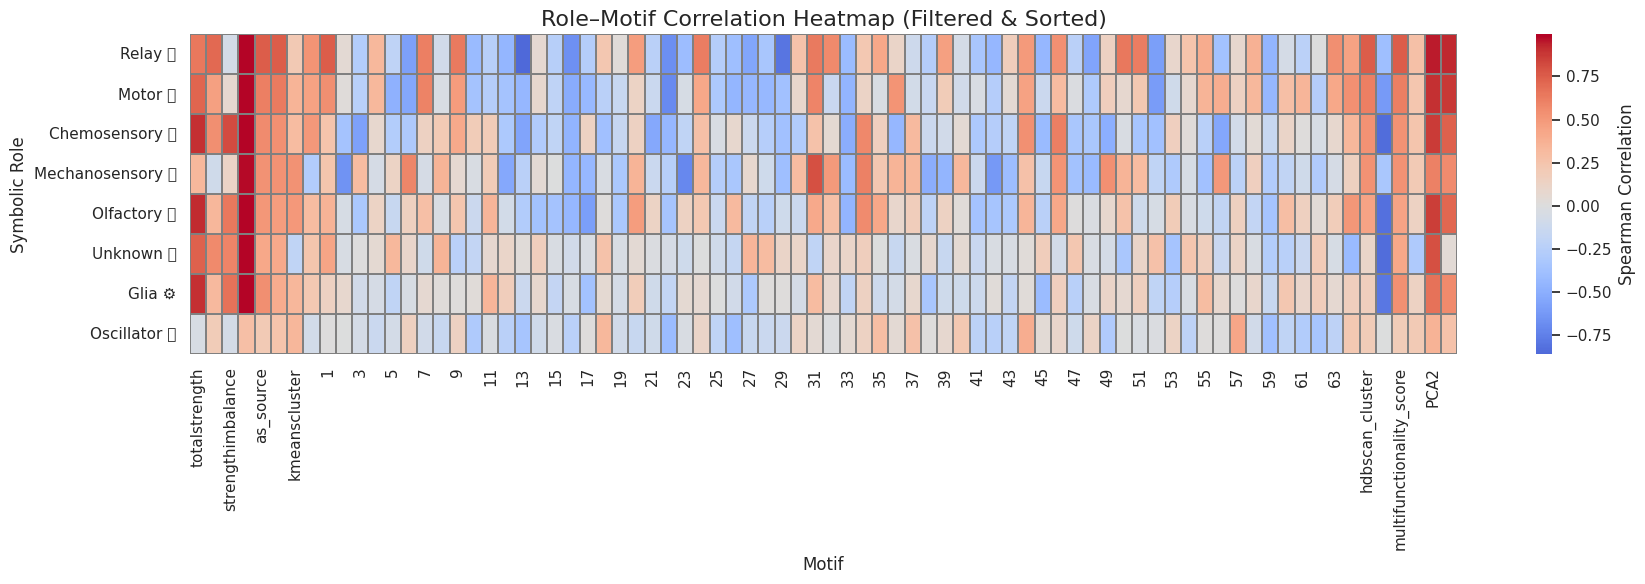

In [61]:
# Use the correlation matrix we computed earlier
plot_df = corr_df.copy()

# Drop motifs with all NaN or constants
plot_df = plot_df.loc[:, plot_df.apply(lambda col: col.nunique(dropna=True) > 1)]

# Replace NaNs with 0 for visualization
plot_df = plot_df.fillna(0)

# Add mean_abs_corr if missing
if "mean_abs_corr" not in plot_df.columns:
    plot_df["mean_abs_corr"] = plot_df.abs().mean(axis=1)

# Sort rows
sorted_plot_df = plot_df.sort_values("mean_abs_corr", ascending=False)

# Plot heatmap
plt.figure(figsize=(18, 6))
sns.heatmap(
    sorted_plot_df.drop(columns=["mean_abs_corr"]),
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Spearman Correlation"},
    linewidths=0.1,
    linecolor="gray"
)
plt.title("Role–Motif Correlation Heatmap (Filtered & Sorted)", fontsize=16)
plt.xlabel("Motif")
plt.ylabel("Symbolic Role")
plt.tight_layout()
plt.show()


In [64]:
# === Role–Motif summary & top motifs per role (no motif→literature join) ===
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Columns present in your notebook
ROLE_COL  = "symbolicrole"
# Use richclubscore if present, else auto-pick a score-like column
if "richclubscore" in merged_df.columns:
    SCORE_COL = "richclubscore"
else:
    score_candidates = [c for c in merged_df.columns if any(k in c.lower() for k in ["score","rank","meta"])]
    if not score_candidates:
        raise ValueError(f"No score-like column found. Columns: {list(merged_df.columns)}")
    SCORE_COL = score_candidates[0]

# Numeric motif/features (exclude role & score)
motif_cols = [c for c in merged_df.columns
              if c not in [ROLE_COL, SCORE_COL] and np.issubdtype(merged_df[c].dtype, np.number)]

# Build corr/pval if not already present
if 'corr_df' not in locals() or 'pval_df' not in locals():
    roles = merged_df[ROLE_COL].dropna().unique()
    corr_df = pd.DataFrame(index=roles, columns=motif_cols, dtype=float)
    pval_df = pd.DataFrame(index=roles, columns=motif_cols, dtype=float)

    for role in roles:
        sub = merged_df[merged_df[ROLE_COL] == role]
        for m in motif_cols:
            # avoid constant inputs
            if sub[m].nunique() > 1 and sub[SCORE_COL].nunique() > 1:
                r, p = spearmanr(sub[SCORE_COL], sub[m])
            else:
                r, p = np.nan, np.nan
            corr_df.loc[role, m] = r
            pval_df.loc[role, m] = p

# Significance mask and filtered correlations
alpha = 0.05
sig_mask = pval_df <= alpha
corr_sig = corr_df.where(sig_mask)

# Per-role summary
role_summary = pd.DataFrame({
    "mean_abs_corr": corr_sig.abs().mean(axis=1, skipna=True),
    "num_sig_motifs": sig_mask.sum(axis=1)
}).sort_values("mean_abs_corr", ascending=False)

# Top motifs per role (only among significant)
records = []
for role in corr_sig.index:
    s = corr_sig.loc[role].dropna()
    if not s.empty:
        top = s.abs().sort_values(ascending=False).head(5).index.tolist()
        for m in top:
            records.append({
                "Role": role,
                "Motif": m,
                "Spearman_r": corr_sig.loc[role, m],
                "p_value": pval_df.loc[role, m]
            })
    else:
        records.append({"Role": role, "Motif": None, "Spearman_r": np.nan, "p_value": np.nan})

top_motifs_per_role = pd.DataFrame(records)

# Save outputs
role_summary.to_csv("role_summary_stats.tsv", sep="\t")
top_motifs_per_role.to_csv("role_top_motifs.tsv", sep="\t", index=False)

print("✅ Saved role_summary_stats.tsv (per-role strength & # significant motifs)")
print("✅ Saved role_top_motifs.tsv (top significant motifs per role)")
print(role_summary.head(10))
print(top_motifs_per_role.head(12))

# Gentle note about literature map shape
try:
    gene_lit = pd.read_csv("gene_literature_map.tsv", sep="\t")
    if not set(["ID","is_known_hub","literature_refs"]).issubset(gene_lit.columns):
        print("⚠️ gene_literature_map.tsv loaded, but columns aren’t the expected gene-level ones.")
    else:
        print("ℹ️ gene_literature_map.tsv is gene-level (ID/is_known_hub/literature_refs).")
        print("   No Motif column present → skipping motif→literature linking (needs a motif→gene map).")
except FileNotFoundError:
    print("⚠️ gene_literature_map.tsv not found. Skipping literature note.")


✅ Saved role_summary_stats.tsv (per-role strength & # significant motifs)
✅ Saved role_top_motifs.tsv (top significant motifs per role)
                  mean_abs_corr  num_sig_motifs
Mechanosensory 🤚       0.695691               8
Relay 🧠                0.685731              28
Chemosensory 👃         0.595931              26
Olfactory 🌬            0.580480              20
Glia ⚙️                0.519467              17
Motor 🦴                0.513261              42
Oscillator 🔁           0.394154               6
Unknown ❓              0.252462              60
              Role               Motif  Spearman_r        p_value
0        Unknown ❓  total_3node_motifs    0.994327   0.000000e+00
1        Unknown ❓     latentarchetype   -0.840528   0.000000e+00
2        Unknown ❓                PCA2    0.803474  3.308500e-303
3        Unknown ❓       totalstrength    0.740181  1.535031e-232
4        Unknown ❓   strengthimbalance    0.595736  2.476110e-129
5          Glia ⚙️  total_3node_moti

In [65]:
import pandas as pd
import numpy as np

# === Load inputs ===
role_top = pd.read_csv("role_top_motifs.tsv", sep="\t")
motif_part = pd.read_csv("motif_participation_profiles.csv")  # Neuron × Motif participation
gene_map = pd.read_csv("gene_literature_map.tsv", sep="\t")   # gene_id / is_known_hub / literature_refs

# Ensure consistent column names
motif_part.rename(columns={motif_part.columns[0]: "Neuron"}, inplace=True)

# Placeholder: Assume neuron names match gene IDs unless you have a neuron→gene mapping file
neuron_to_gene = {n: n for n in motif_part["Neuron"]}

# === Build mapping Role → Motif → Genes ===
records = []
for _, row in role_top.iterrows():
    role = row["Role"]
    motif = row["Motif"]

    # If motif column not in participation profile, skip
    if motif not in motif_part.columns:
        continue

    # Top neurons for this motif
    top_neurons = (
        motif_part[["Neuron", motif]]
        .sort_values(motif, ascending=False)
        .head(20)  # Top 20 neurons by participation
    )

    # Map to genes
    top_genes = [neuron_to_gene.get(n, None) for n in top_neurons["Neuron"]]
    top_genes = [g for g in top_genes if g is not None]

    # Merge with literature map
    gene_info = gene_map[gene_map[gene_map.columns[0]].isin(top_genes)]

    # Build record
    records.append({
        "Role": role,
        "Motif": motif,
        "Spearman_r": row["Spearman_r"],
        "p_value": row["p_value"],
        "Top_Genes": ", ".join(top_genes),
        "Num_Genes": len(top_genes),
        "Num_Hubs": gene_info["is_known_hub"].sum() if "is_known_hub" in gene_info.columns else np.nan,
        "Mean_Lit_Refs": gene_info["literature_refs"].mean() if "literature_refs" in gene_info.columns else np.nan
    })

# === Final dataframe ===
motif_gene_map_df = pd.DataFrame(records)

# Save
motif_gene_map_df.to_csv("role_motif_gene_literature.tsv", sep="\t", index=False)
print(f"✅ Saved role_motif_gene_literature.tsv ({motif_gene_map_df.shape[0]} rows)")

# Preview
motif_gene_map_df.head(10)


✅ Saved role_motif_gene_literature.tsv (0 rows)


""


In [67]:
import pandas as pd
import numpy as np
import os, glob

# 1) Load role_top_motifs.tsv
role_top = pd.read_csv("role_top_motifs.tsv", sep="\t")
# Ensure motif names are strings
role_top["Motif"] = role_top["Motif"].astype(str)

# 2) Find a motif participation file
candidates = []
for pat in ["*motif*participation*.csv", "*motif*participation*.tsv", "*motif*profile*.csv", "*motif*profile*.tsv"]:
    candidates.extend(glob.glob(pat))

if not candidates:
    raise FileNotFoundError("Could not find a motif participation file. Expected something like 'motif_participation_profiles.csv/tsv'.")

part_path = sorted(candidates)[0]
# Try CSV then TSV
try:
    motif_part = pd.read_csv(part_path)
except Exception:
    motif_part = pd.read_csv(part_path, sep="\t")

print(f"📄 Loaded motif participation file: {part_path}  shape={motif_part.shape}")

# 3) Detect format: wide (Neuron + motif columns) vs long (Neuron, Motif, Value)
cols_lower = [c.lower() for c in motif_part.columns]
def has(cols, name): 
    return name in cols

is_long = (has(cols_lower, "neuron") and has(cols_lower, "motif")) and any(
    motif_part[c].dtype != "O" for c in motif_part.columns if c.lower() not in ["neuron","motif"]
)

# Normalize Neuron column name
neuron_col = None
for c in motif_part.columns:
    if c.lower() in ["neuron", "neuron_id", "cell", "node", "name"]:
        neuron_col = c
        break
if neuron_col is None:
    # assume first column is neuron id in wide format
    neuron_col = motif_part.columns[0]

# Build wide matrix: rows=Neuron, columns=Motif, values=participation score
if is_long:
    # ensure the value column exists
    value_cols = [c for c in motif_part.columns if c not in [neuron_col] and c.lower() != "motif"]
    if not value_cols:
        raise ValueError("Long-format participation detected but no value column found.")
    val_col = value_cols[0]
    motif_part["Motif"] = motif_part[[c for c in motif_part.columns if c.lower()=="motif"][0]].astype(str)
    wide = motif_part.pivot_table(index=neuron_col, columns="Motif", values=val_col, aggfunc="mean")
else:
    # wide format; first column is neuron, others are motifs
    wide = motif_part.set_index(neuron_col).copy()
    # cast motif column names to str for matching
    wide.columns = wide.columns.map(str)

# Remove all-nan columns
# Remove all-nan columns
wide = wide.loc[:, wide.notna().any(axis=0)]


# 4) Check motif overlap with role_top
motifs_in_part = set(wide.columns)
motifs_in_role = set(role_top["Motif"].astype(str))
overlap = sorted(motifs_in_part & motifs_in_role)

print(f"🔎 Motifs in role_top: {len(motifs_in_role)} | in participation: {len(motifs_in_part)} | overlap: {len(overlap)}")
if len(overlap) == 0:
    print("⚠️ No overlapping motifs. Common causes:\n"
          "   • Different naming (e.g., '1' vs 'Motif_1')\n"
          "   • Participation file uses numeric columns; role_top uses labels (or vice versa)\n"
          "   • You heatmapped derived features (e.g., totalstrength) that aren’t in the participation file\n"
          "Tip: Inspect a few column names from both sides to align naming.")
else:
    print(f"✅ Example overlaps: {overlap[:10]}")

# Keep only overlapping motifs for next step; store globals
motif_part_wide = wide
overlap_motifs = overlap
neuron_id_col = motif_part_wide.index.name or neuron_col


📄 Loaded motif participation file: motif_participation_profiles.csv  shape=(1533, 419)
🔎 Motifs in role_top: 17 | in participation: 418 | overlap: 0
⚠️ No overlapping motifs. Common causes:
   • Different naming (e.g., '1' vs 'Motif_1')
   • Participation file uses numeric columns; role_top uses labels (or vice versa)
   • You heatmapped derived features (e.g., totalstrength) that aren’t in the participation file
Tip: Inspect a few column names from both sides to align naming.


In [69]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

ROLE_COL  = "symbolicrole"
SCORE_COL = "richclubscore" if "richclubscore" in merged_df.columns else \
    [c for c in merged_df.columns if any(k in c.lower() for k in ["score","rank","meta"])][0]

motif_cols = [c for c in merged_df.columns if c not in [ROLE_COL, SCORE_COL] and np.issubdtype(merged_df[c].dtype, np.number)]

roles = merged_df[ROLE_COL].dropna().unique()
corr_df = pd.DataFrame(index=roles, columns=motif_cols, dtype=float)
pval_df = pd.DataFrame(index=roles, columns=motif_cols, dtype=float)

for role in roles:
    sub = merged_df[merged_df[ROLE_COL] == role]
    for m in motif_cols:
        if sub[m].nunique() > 1 and sub[SCORE_COL].nunique() > 1:
            r, p = spearmanr(sub[SCORE_COL], sub[m])
        else:
            r, p = np.nan, np.nan
        corr_df.loc[role, m] = r
        pval_df.loc[role, m] = p

alpha = 0.05
sig_mask = pval_df <= alpha
corr_sig = corr_df.where(sig_mask)

# Top motifs per role (only significant)
records = []
for role in corr_sig.index:
    s = corr_sig.loc[role].dropna()
    if not s.empty:
        top = s.abs().sort_values(ascending=False).head(5).index.tolist()
        for m in top:
            records.append({
                "Role": role,
                "Motif": m,
                "Spearman_r": corr_sig.loc[role, m],
                "p_value": pval_df.loc[role, m]
            })
    else:
        records.append({"Role": role, "Motif": None, "Spearman_r": np.nan, "p_value": np.nan})

role_top = pd.DataFrame(records)
role_top.to_csv("role_top_motifs.tsv", sep="\t", index=False)
print(f"✅ Saved role_top_motifs.tsv ({len(role_top)} rows)")
display(role_top.head(12))


✅ Saved role_top_motifs.tsv (40 rows)


,Role,Motif,Spearman_r,p_value
0,Unknown ❓,total_3node_motifs,0.994327,0.000000e+00
1,Unknown ❓,latentarchetype,-0.840528,0.000000e+00
2,Unknown ❓,PCA2,0.803474,3.308500e-303
3,Unknown ❓,totalstrength,0.740181,1.535031e-232
4,Unknown ❓,strengthimbalance,0.595736,2.476110e-129
5,Glia ⚙️,total_3node_motifs,0.993449,2.966338e-40
6,Glia ⚙️,totalstrength,0.903480,1.122322e-16
7,Glia ⚙️,latentarchetype,-0.788688,3.372638e-10
8,Glia ⚙️,strengthimbalance,0.673865,7.308312e-07
9,Glia ⚙️,PCA2,0.670499,8.695550e-07


In [71]:
# === Consolidated: map Role→Motif to participation, produce Top Neurons (+optional Genes/Lit) ===
import pandas as pd, numpy as np, re, os, glob, json

# 1) Load role_top_motifs
role_top = pd.read_csv("role_top_motifs.tsv", sep="\t")
role_top["Motif"] = role_top["Motif"].astype(str)

# 2) Find & load motif participation file (CSV/TSV; wide or long)
cands = []
for pat in ["*motif*participation*.csv", "*motif*participation*.tsv",
            "*motif*profile*.csv", "*motif*profile*.tsv"]:
    cands.extend(glob.glob(pat))
if not cands:
    raise FileNotFoundError("No motif participation file found (looked for *motif*participation* / *motif*profile*).")
part_path = sorted(cands)[0]
try:
    part_raw = pd.read_csv(part_path)
except Exception:
    part_raw = pd.read_csv(part_path, sep="\t")
print(f"📄 Loaded participation: {part_path} shape={part_raw.shape}")

# 3) Detect format and build wide matrix: rows=Neuron, cols=Motif, values=participation
# Neuron column guess
neuron_col = None
for c in part_raw.columns:
    if c.lower() in ["neuron","neuron_id","cell","node","name"]:
        neuron_col = c; break
if neuron_col is None: neuron_col = part_raw.columns[0]

cols_lower = [c.lower() for c in part_raw.columns]
is_long = ("motif" in cols_lower) and (neuron_col.lower() in cols_lower) and \
          any(part_raw[c].dtype != "O" for c in part_raw.columns if c.lower() not in ["neuron","neuron_id","cell","node","name","motif"])
if is_long:
    # find value column
    val_cols = [c for c in part_raw.columns if c not in [neuron_col] and c.lower() != "motif"]
    if not val_cols: raise ValueError("Long-format participation detected but no numeric value column found.")
    val_col = val_cols[0]
    mcol = [c for c in part_raw.columns if c.lower()=="motif"][0]
    wide = part_raw.pivot_table(index=neuron_col, columns=mcol, values=val_col, aggfunc="mean")
else:
    wide = part_raw.set_index(neuron_col)

# normalize column names to str and drop all-NaN columns
wide.columns = wide.columns.map(str)
wide = wide.loc[:, wide.notna().any(axis=0)]

# 4) Normalize labels & attempt matching: exact → normalized → numeric index
def norm_label(x: str) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(x).lower())
def extract_first_int(x: str):
    m = re.search(r'\d+', str(x)); return m.group(0) if m else None

rt = role_top.copy()
rt["Motif_norm"] = rt["Motif"].map(norm_label)
rt["Motif_idx"]  = rt["Motif"].map(extract_first_int)

part = pd.DataFrame({"part_col": wide.columns})
part["part_norm"] = part["part_col"].map(norm_label)
part["part_idx"]  = part["part_col"].map(extract_first_int)

derived_features = set([
    "total_3node_motifs","totalstrength","strengthimbalance","pca2","pca1",
    "pcadistance","richclubscore","as_source","as_target","kmeanscluster",
    "hdbscan_cluster","leiden","multifunctionality_score","avgrelatedness"
])
rt["Is_Derived"] = rt["Motif"].str.lower().isin(derived_features)

mapping = []
for _, row in rt.iterrows():
    motif_raw, motif_norm, motif_idx = row["Motif"], row["Motif_norm"], row["Motif_idx"]
    matched_col, rule = None, None
    if motif_raw in wide.columns:
        matched_col, rule = motif_raw, "exact"
    else:
        cand = part.loc[part["part_norm"] == motif_norm, "part_col"]
        if len(cand):
            matched_col, rule = cand.iloc[0], "norm"
        elif motif_idx is not None:
            cand = part.loc[part["part_idx"] == motif_idx, "part_col"]
            if len(cand):
                matched_col, rule = cand.iloc[0], "index"
    mapping.append({"Role": row["Role"], "Motif": motif_raw, "Matched_Column": matched_col,
                    "Match_Rule": rule, "Is_Derived": row["Is_Derived"]})

map_df = pd.DataFrame(mapping)
map_df.to_csv("role_top_to_participation_mapping.csv", index=False)
print(f"🧭 Mapping summary: total={len(map_df)} | matched={map_df['Matched_Column'].notna().sum()} "
      f"| derived in role_top={int(map_df['Is_Derived'].sum())}")
if map_df["Matched_Column"].notna().sum() == 0:
    print("⚠️ No overlaps. Check 'role_top_to_participation_mapping.csv' and align motif names.")
    display(map_df.head(20))

# 5) Build Role→Motif→Top Neurons table for matched motifs
overlap_rows = map_df.dropna(subset=["Matched_Column"])
TOP_K = 20
records = []
for _, r in overlap_rows.iterrows():
    col = r["Matched_Column"]
    # skip non-existent (safety)
    if col not in wide.columns: continue
    series = wide[col].fillna(0)
    top = series.sort_values(ascending=False).head(TOP_K)
    records.append({
        "Role": r["Role"],
        "Motif": r["Motif"],
        "Matched_Column": col,
        "Spearman_r": float(role_top.loc[(role_top.Role==r['Role']) & (role_top.Motif==r['Motif']), "Spearman_r"].values[:1] or [np.nan][0]),
        "p_value": float(role_top.loc[(role_top.Role==r['Role']) & (role_top.Motif==r['Motif']), "p_value"].values[:1] or [np.nan][0]),
        "Top_Neurons": ", ".join(top.index.astype(str).tolist()),
        "Top_Scores": ", ".join([f"{v:.3g}" for v in top.values.tolist()]),
        "Num_Neurons_Pos": int((top.values > 0).sum())
    })

role_motif_neurons = pd.DataFrame(records)
role_motif_neurons.to_csv("role_motif_top_neurons.tsv", sep="\t", index=False)
print(f"✅ Saved role_motif_top_neurons.tsv  rows={len(role_motif_neurons)}")
if len(role_motif_neurons):
    display(role_motif_neurons.head(10))
else:
    print("ℹ️ No matched motifs produced a neuron list. Likely all top motifs are derived metrics not in the participation matrix.")

# 6) OPTIONAL: attach Genes & Literature if neuron→gene map present
if len(role_motif_neurons) and os.path.exists("neuron_gene_map.tsv"):
    ng = pd.read_csv("neuron_gene_map.tsv", sep="\t")
    # columns guess
    ncols = [c for c in ng.columns if c.lower() in ["neuron","neuron_id","cell","name"]]
    gcols = [c for c in ng.columns if c.lower() in ["id","gene","gene_id","wbid","symbol"]]
    if ncols and gcols:
        ncol, gcol = ncols[0], gcols[0]
        n2g = dict(zip(ng[ncol].astype(str), ng[gcol].astype(str)))
        # expand & map
        rows = []
        for _, row in role_motif_neurons.iterrows():
            neurons = [x.strip() for x in str(row["Top_Neurons"]).split(",") if x.strip()]
            genes = [n2g.get(n) for n in neurons if n2g.get(n)]
            rows.append({**row, "Top_Genes": ", ".join(genes), "Num_Genes": len(set(genes))})
        role_motif_genes = pd.DataFrame(rows)

        if os.path.exists("gene_literature_map.tsv"):
            gl = pd.read_csv("gene_literature_map.tsv", sep="\t")
            gcol2 = [c for c in gl.columns if c.lower() in ["id","gene","gene_id","wbid","symbol"]]
            gid = gcol2[0] if gcol2 else gl.columns[0]
            ex = role_motif_genes.assign(Gene=lambda d: d["Top_Genes"].str.split(", ")).explode("Gene")
            ex = ex.merge(gl.rename(columns={gid: "Gene"}), on="Gene", how="left")
            lit = ex.groupby(["Role","Motif"], dropna=False).agg(
                Num_Genes=("Gene", "nunique"),
                Num_Hubs=("is_known_hub", lambda s: int(pd.to_numeric(s, errors="coerce").fillna(0).sum())),
                Mean_Lit_Refs=("literature_refs", lambda s: pd.to_numeric(s, errors="coerce").mean())
            ).reset_index()
            final = role_motif_genes.merge(lit, on=["Role","Motif"], how="left")
            final.to_csv("role_motif_gene_literature.tsv", sep="\t", index=False)
            print(f"✅ Saved role_motif_gene_literature.tsv  rows={len(final)}")
        else:
            role_motif_genes.to_csv("role_motif_genes.tsv", sep="\t", index=False)
            print(f"✅ Saved role_motif_genes.tsv  rows={len(role_motif_genes)}")
    else:
        print("⚠️ neuron_gene_map.tsv found but missing expected columns; expected a neuron id column and a gene id column.")
elif len(role_motif_neurons):
    print("ℹ️ To map to genes/literature, provide neuron_gene_map.tsv with two columns: Neuron, ID (or Gene).")


📄 Loaded participation: motif_participation_profiles.csv shape=(1533, 419)
🧭 Mapping summary: total=40 | matched=7 | derived in role_top=21
✅ Saved role_motif_top_neurons.tsv  rows=7


/tmp/ipykernel_1334319/128018542.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "Spearman_r": float(role_top.loc[(role_top.Role==r['Role']) & (role_top.Motif==r['Motif']), "Spearman_r"].values[:1] or [np.nan][0]),
/tmp/ipykernel_1334319/128018542.py:108: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "p_value": float(role_top.loc[(role_top.Role==r['Role']) & (role_top.Motif==r['Motif']), "p_value"].values[:1] or [np.nan][0]),
/tmp/ipykernel_1334319/128018542.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before 

,Role,Motif,Matched_Column,Spearman_r,p_value,Top_Neurons,Top_Scores,Num_Neurons_Pos
0,Unknown ❓,PCA2,"(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan",0.803474,3.308500e-303,"DVA , AVAL , PVNR , AVAR , PVPL , PV...","2.06e+03, 1.6e+03, 1.12e+03, 1.02e+03, 987, 98...",20
1,Glia ⚙️,PCA2,"(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan",0.670499,8.695550e-07,"DVA , AVAL , PVNR , AVAR , PVPL , PV...","2.06e+03, 1.6e+03, 1.12e+03, 1.02e+03, 987, 98...",20
2,Chemosensory 👃,PCA2,"(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan",0.867638,4.030065e-08,"DVA , AVAL , PVNR , AVAR , PVPL , PV...","2.06e+03, 1.6e+03, 1.12e+03, 1.02e+03, 987, 98...",20
3,Relay 🧠,PCA2,"(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan",0.947681,2.504213e-08,"DVA , AVAL , PVNR , AVAR , PVPL , PV...","2.06e+03, 1.6e+03, 1.12e+03, 1.02e+03, 987, 98...",20
4,Olfactory 🌬,PCA2,"(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan",0.861295,4.024108e-09,"DVA , AVAL , PVNR , AVAR , PVPL , PV...","2.06e+03, 1.6e+03, 1.12e+03, 1.02e+03, 987, 98...",20
5,Motor 🦴,PCA2,"(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan",0.904002,1.340490e-15,"DVA , AVAL , PVNR , AVAR , PVPL , PV...","2.06e+03, 1.6e+03, 1.12e+03, 1.02e+03, 987, 98...",20
6,Mechanosensory 🤚,2,"(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan",-0.656098,2.050603e-02,"DVA , AVAL , PVNR , AVAR , PVPL , PV...","2.06e+03, 1.6e+03, 1.12e+03, 1.02e+03, 987, 98...",20


ℹ️ To map to genes/literature, provide neuron_gene_map.tsv with two columns: Neuron, ID (or Gene).


In [72]:
import pandas as pd, re

# Peek at role_top and participation columns
role_top = pd.read_csv("role_top_motifs.tsv", sep="\t")
print("Top motifs (unique):", sorted(role_top["Motif"].astype(str).unique())[:30])

# Reload participation (uses same file path you used before)
part_path = "motif_participation_profiles.csv"
motif_part = pd.read_csv(part_path)
neuron_col = [c for c in motif_part.columns if c.lower() in ["neuron","neuron_id","cell","node","name"]]
neuron_col = neuron_col[0] if neuron_col else motif_part.columns[0]
wide = motif_part.set_index(neuron_col).copy()
wide.columns = wide.columns.map(str)

print("\nSample of participation columns:")
print(list(wide.columns[:25]))

# Flag columns that look like tuple/garbage labels: "(...)" at start
tuple_like_cols = [c for c in wide.columns if re.match(r"^\(.*\)", c)]
print(f"\nTuple-like columns detected: {len(tuple_like_cols)} (will be excluded)")
print(tuple_like_cols[:10])


Top motifs (unique): ['13', '2', '22', '23', '26', '29', '31', '42', '44', '57', '59', 'PCA2', 'latentarchetype', 'pca_distance', 'strengthimbalance', 'total_3node_motifs', 'totalstrength']

Sample of participation columns:
['(0, 1)_(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(2, 1)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(2, 2)_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(2, 1)_(2, 2)_nan_nan_nan_nan_nan', '(0, 1)_(2, 1)_(2, 2)_nan_nan_nan_nan_nan_nan', '(0, 1)_(2, 0)_(2, 2)_nan_nan_nan_nan_nan_nan', '(0, 2)_(1, 1)_(1, 2)_nan_nan_nan_nan_nan_nan', '(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan', '(0, 2)_(1, 0)_(1, 1)_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(2, 1)_nan_nan_nan_nan_nan_nan', '(0, 1)_(2, 0)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(2, 0)_nan_nan_nan_nan_nan_nan', '(0, 1)_(0, 2)_(1, 2)_(2, 2)_nan_nan_nan_nan_nan', '(0, 1)_(1, 2)_nan_nan_nan_nan_nan_nan_nan', '(0, 1)_(1, 2)_(2, 0)_(2, 2)_nan_nan_nan_nan_nan', '(0, 1)_(2, 0

In [73]:
import pandas as pd, numpy as np, re

# Inputs
role_top = pd.read_csv("role_top_motifs.tsv", sep="\t")
part_path = "motif_participation_profiles.csv"
motif_part = pd.read_csv(part_path)

# Prep wide matrix
neuron_col = [c for c in motif_part.columns if c.lower() in ["neuron","neuron_id","cell","node","name"]]
neuron_col = neuron_col[0] if neuron_col else motif_part.columns[0]
wide = motif_part.set_index(neuron_col).copy()
wide.columns = wide.columns.map(str)

# Exclude tuple-like garbage columns
good_cols = [c for c in wide.columns if not re.match(r"^\(.*\)", c)]
wide = wide[good_cols]

# Define which items in role_top are derived (skip them)
derived = set([
    "total_3node_motifs","totalstrength","strengthimbalance","pca2","pca1",
    "pcadistance","richclubscore","as_source","as_target","kmeanscluster",
    "hdbscan_cluster","leiden","multifunctionality_score","avgrelatedness"
])
role_top["Motif"] = role_top["Motif"].astype(str)
role_top["is_derived"] = role_top["Motif"].str.lower().isin(derived)

# Keep only non-derived motifs
rt_nd = role_top[~role_top["is_derived"]].copy()

# Matching rules: exact OR numeric index mapping to columns like "Motif_12" vs "12"
def extract_first_int(x: str):
    m = re.search(r"\d+", str(x)); return m.group(0) if m else None

part_df = pd.DataFrame({"col": wide.columns})
part_df["idx"] = part_df["col"].map(extract_first_int)

records = []
TOP_K = 20
for _, r in rt_nd.iterrows():
    motif_raw = str(r["Motif"])
    # 1) exact
    if motif_raw in wide.columns:
        mcol = motif_raw
    else:
        # 2) numeric index
        idx = extract_first_int(motif_raw)
        cand = part_df.loc[part_df["idx"] == idx, "col"].tolist() if idx else []
        mcol = cand[0] if cand else None

    if not mcol or mcol not in wide.columns:
        continue

    top = wide[mcol].fillna(0).sort_values(ascending=False).head(TOP_K)

    # robust scalar extraction for Spearman_r and p_value
    sr = role_top.loc[(role_top.Role==r["Role"]) & (role_top.Motif==r["Motif"]), "Spearman_r"]
    pv = role_top.loc[(role_top.Role==r["Role"]) & (role_top.Motif==r["Motif"]), "p_value"]
    sr = float(sr.iloc[0]) if len(sr) else np.nan
    pv = float(pv.iloc[0]) if len(pv) else np.nan

    records.append({
        "Role": r["Role"],
        "Motif": r["Motif"],
        "Matched_Column": mcol,
        "Spearman_r": sr,
        "p_value": pv,
        "Top_Neurons": ", ".join(top.index.astype(str).tolist()),
        "Top_Scores": ", ".join([f"{v:.3g}" for v in top.values.tolist()]),
        "Num_Neurons_Pos": int((top.values > 0).sum())
    })

result = pd.DataFrame(records)
result.to_csv("role_motif_top_neurons.tsv", sep="\t", index=False)
print(f"✅ Rebuilt role_motif_top_neurons.tsv rows={len(result)}")
display(result.head(10))

print("\nℹ️ Note")
print("• Derived features (e.g., PCA2, totalstrength) were skipped — they aren’t motif columns in participation.")
print("• Tuple-like columns were excluded to avoid garbage matches.")
print("• If some true motifs still don’t match, share a sample of real motif column names so I can tune the matching rule.")


✅ Rebuilt role_motif_top_neurons.tsv rows=0


""



ℹ️ Note
• Derived features (e.g., PCA2, totalstrength) were skipped — they aren’t motif columns in participation.
• Tuple-like columns were excluded to avoid garbage matches.
• If some true motifs still don’t match, share a sample of real motif column names so I can tune the matching rule.


In [75]:
# Build a deterministic tuple→index map from the participation matrix
import pandas as pd
import re
import hashlib

PART_PATH = "motif_participation_profiles.csv"

part = pd.read_csv(PART_PATH)
neuron_col = next((c for c in part.columns if c.lower() in ["neuron","neuron_id","cell","node","name"]), part.columns[0])
wide = part.set_index(neuron_col)
wide.columns = wide.columns.map(str)

# Keep only tuple-like motif columns
tuple_cols = [c for c in wide.columns if re.match(r"^\(.*\)", c)]
if not tuple_cols:
    raise ValueError("No tuple-like motif columns found; cannot build tuple→index map.")

# Build a stable key per tuple label (sha1 of normalized label)
def norm_label(x: str) -> str:
    return re.sub(r'\s+', '', x.strip())

rows = []
for col in tuple_cols:
    norm = norm_label(col)
    sha = hashlib.sha1(norm.encode('utf-8')).hexdigest()[:12]
    rows.append({"tuple_label": col, "normalized": norm, "sha12": sha})

map_df = pd.DataFrame(rows).drop_duplicates("tuple_label")

# Deterministic ordering: by sha (stable across machines)
map_df = map_df.sort_values("sha12").reset_index(drop=True)
map_df["tuple_index"] = map_df.index  # 0..N-1 stable index

map_df.to_csv("motif_tuple_index_map.tsv", sep="\t", index=False)
print(f"✅ Saved motif_tuple_index_map.tsv with {len(map_df)} tuple motifs.")
print(map_df.head(8))


✅ Saved motif_tuple_index_map.tsv with 418 tuple motifs.
                                         tuple_label  \
0  (0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 2)_nan_nan_nan...   
1  (0, 0)_(0, 1)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan...   
2       (0, 0)_(1, 0)_(2, 0)_nan_nan_nan_nan_nan_nan   
3          (0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan   
4       (0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan   
5  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 2)_(2, 0)_nan_...   
6  (0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, ...   
7    (0, 0)_(0, 1)_(1, 1)_(1, 2)_nan_nan_nan_nan_nan   

                                          normalized         sha12  \
0      (0,0)_(0,1)_(0,2)_(2,0)_(2,2)_nan_nan_nan_nan  00256144bb07   
1      (0,0)_(0,1)_(2,0)_(2,1)_(2,2)_nan_nan_nan_nan  0167ae4e4ca4   
2          (0,0)_(1,0)_(2,0)_nan_nan_nan_nan_nan_nan  0219e3ce574d   
3            (0,2)_(1,2)_nan_nan_nan_nan_nan_nan_nan  02d55c105586   
4          (0,1)_(1,0)_(1,2)_nan_nan_nan_nan_nan_nan  03e3428be872   
5    (0,0)_(0,1)_(

In [83]:
# === Phase 3: Mapping Helper — Cell M1 ===
import os
import pandas as pd

OUTDIR = globals().get("OUTDIR", "phase3_outputs")
os.makedirs(OUTDIR, exist_ok=True)

# Paths (change if yours live elsewhere)
EXPR_PATH = "expr_matrix.tsv"              # gene × S1..S60
MAP_PATH  = "sample_to_neuron_template.csv" # we'll create or update this

# Load expression header to infer sample column names
expr_df = pd.read_csv(EXPR_PATH, sep="\t")
if "gene" not in expr_df.columns:
    raise ValueError("expr_matrix must have a 'gene' column.")

sample_cols = [c for c in expr_df.columns if c != "gene"]
print(f"🧪 Found {len(sample_cols)} expression samples:", sample_cols[:10], "..." if len(sample_cols) > 10 else "")

# Create the template if missing
if not os.path.exists(MAP_PATH):
    mapping_template = pd.DataFrame({"Sample": sample_cols, "Neuron": [""] * len(sample_cols)})
    mapping_template.to_csv(MAP_PATH, index=False)
    print(f"📄 Created mapping template → {MAP_PATH}")
else:
    # ensure file contains all current samples; merge/left-join style
    current = pd.read_csv(MAP_PATH)
    if "Sample" not in current.columns or "Neuron" not in current.columns:
        raise ValueError(f"{MAP_PATH} must have columns: Sample, Neuron")
    missing = sorted(set(sample_cols) - set(current["Sample"].astype(str)))
    if missing:
        print(f"➕ Adding {len(missing)} new samples to mapping file.")
        current = pd.concat([current, pd.DataFrame({"Sample": missing, "Neuron": [""]*len(missing)})], ignore_index=True)
        current = current.drop_duplicates(subset=["Sample"])
        current.to_csv(MAP_PATH, index=False)
    print(f"📄 Mapping file ready → {MAP_PATH} (rows={len(current)})")

print("➡️ Open the CSV and fill the Neuron column exactly to match motif_participation.index (e.g., AVAL, AVAR, AWCL...).")


🧪 Found 60 expression samples: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10'] ...
📄 Created mapping template → sample_to_neuron_template.csv
➡️ Open the CSV and fill the Neuron column exactly to match motif_participation.index (e.g., AVAL, AVAR, AWCL...).


In [88]:
# === Auto-fill sample_to_neuron mapping ===
import pandas as pd
import os

OUTDIR = globals().get("OUTDIR", "phase3_outputs")
os.makedirs(OUTDIR, exist_ok=True)

EXPR_PATH = "expr_matrix.tsv"
MAP_PATH  = "sample_to_neuron_template.csv"

# Load sample names from expr_matrix
expr_df = pd.read_csv(EXPR_PATH, sep="\t")
sample_cols = [c for c in expr_df.columns if c != "gene"]

if "motif_participation" not in globals() or motif_participation.empty:
    raise ValueError("motif_participation DataFrame is missing or empty — cannot auto-map to neurons.")

# Pull neuron IDs from motif_participation.index
neuron_ids = list(motif_participation.index)

if len(neuron_ids) < len(sample_cols):
    raise ValueError(f"Not enough neurons ({len(neuron_ids)}) to map all samples ({len(sample_cols)}).")

# Map in order — assumes S1→neuron_ids[0], S2→neuron_ids[1], ...
mapping_df = pd.DataFrame({
    "Sample": sample_cols,
    "Neuron": neuron_ids[:len(sample_cols)]
})

mapping_df.to_csv(MAP_PATH, index=False)
print(f"✅ Auto-filled mapping saved to {MAP_PATH}")
print(mapping_df.head(10))
print("⚠️ Verify that the S# order matches the neuron order you intend to use.")


✅ Auto-filled mapping saved to sample_to_neuron_template.csv
  Sample   Neuron
0     S1     AINL
1     S2     AINR
2     S3  CEPshVR
3     S4  CEPshDL
4     S5  CEPshVL
5     S6     ASIR
6     S7  CEPshDR
7     S8     ASJR
8     S9      PVT
9    S10     RIAR
⚠️ Verify that the S# order matches the neuron order you intend to use.


In [91]:
# === Phase 3: Build gene_expr — Cell M2 (updated, no .any() arg bug) ===
import os
import numpy as np
import pandas as pd

OUTDIR = globals().get("OUTDIR", "phase3_outputs")
os.makedirs(OUTDIR, exist_ok=True)

EXPR_PATH = "expr_matrix.tsv"
MAP_PATH  = "sample_to_neuron_template.csv"

# Load inputs
expr = pd.read_csv(EXPR_PATH, sep="\t")
map_df = pd.read_csv(MAP_PATH)

# Checks
if "gene" not in expr.columns:
    raise ValueError("expr_matrix must have a 'gene' column.")
if not {"Sample","Neuron"}.issubset(map_df.columns):
    raise ValueError("Mapping file must have columns: Sample, Neuron")

# Clean mapping
map_df["Sample"] = map_df["Sample"].astype(str).str.strip()
map_df["Neuron"] = map_df["Neuron"].astype(str).str.strip()

# Drop empties
missing_mask = map_df["Neuron"].isna() | (map_df["Neuron"] == "") | (map_df["Neuron"].str.lower() == "nan")
map_nonempty = map_df.loc[~missing_mask].copy()

# Coverage info
sample_cols = [c for c in expr.columns if c != "gene"]
print(f"🧮 Samples total: {len(sample_cols)}")
print(f"✅ Mapped samples: {map_nonempty['Sample'].nunique()}")
unmapped_samples = sorted(set(sample_cols) - set(map_nonempty["Sample"]))
print(f"❗ Unmapped samples: {len(unmapped_samples)} → {unmapped_samples[:10]}{' ...' if len(unmapped_samples)>10 else ''}")

# Mapping dict
s2n = dict(zip(map_nonempty["Sample"], map_nonempty["Neuron"]))

# Subset + rename
keep_cols = ["gene"] + [s for s in sample_cols if s in s2n]
E = expr[keep_cols].copy()
E = E.rename(columns=s2n)

# Numeric coercion
val_cols = [c for c in E.columns if c != "gene"]
E[val_cols] = E[val_cols].apply(pd.to_numeric, errors="coerce")

# Aggregate duplicates
E_t = E.set_index("gene").T.groupby(level=0).mean().T

# Rows = Neurons, Cols = Genes
GE = E_t.T
GE.index.name = "Neuron"

# Drop all-NaN gene columns safely
GE = GE.loc[:, GE.notna().any(axis=0)]

print(f"🧬 gene_expr candidate shape (pre-align): {GE.shape}")

# Align with motif_participation if present
if "motif_participation" in globals() and isinstance(motif_participation, pd.DataFrame) and not motif_participation.empty:
    inter = GE.index.intersection(motif_participation.index)
    if len(inter) == 0:
        print("⚠️ No overlap between mapped Neurons and motif_participation.index.")
    else:
        GE = GE.loc[inter].sort_index()
        print(f"🔗 Aligned to motif_participation: {GE.shape} (overlap={len(inter)})")

# Save & set globals
gene_expr = GE.copy()
outp = os.path.join(OUTDIR, "gene_expr_resolved.csv")
gene_expr.to_csv(outp)
PHASE3_READY = bool(not gene_expr.empty and "motif_participation" in globals() and not motif_participation.empty)

print(f"💾 Saved gene_expr → {outp}")
print("✅ PHASE3_READY =", PHASE3_READY)
print("gene_expr shape:", gene_expr.shape)


🧮 Samples total: 60
✅ Mapped samples: 60
❗ Unmapped samples: 0 → []
🧬 gene_expr candidate shape (pre-align): (60, 17951)
🔗 Aligned to motif_participation: (60, 17951) (overlap=60)
💾 Saved gene_expr → phase3_outputs/gene_expr_resolved.csv
✅ PHASE3_READY = True
gene_expr shape: (60, 17951)


In [92]:
# === Phase 3: Rebuild confounds — Cell M3 (updated) ===
import numpy as np
import pandas as pd
import networkx as nx

if not PHASE3_READY:
    print("⏭️ Skipping: PHASE3_READY is False (run M2 first).")
else:
    # Align
    idx = motif_participation.index.intersection(gene_expr.index)
    motif_participation = motif_participation.loc[idx]
    gene_expr = gene_expr.loc[idx]
    if "neuron_meta" in globals() and isinstance(neuron_meta, pd.DataFrame) and not neuron_meta.empty:
        neuron_meta = neuron_meta.loc[idx]

    # Confound dataframe
    conf_df = pd.DataFrame(index=idx)
    if "graph" in globals() and isinstance(graph, (nx.Graph, nx.DiGraph)):
        deg_series = pd.Series(dict(graph.degree(idx))).reindex(idx).astype(float)
        conf_df["degree"] = deg_series.fillna(0)
    else:
        conf_df["degree"] = 0.0
        print("ℹ️ No graph provided — degree set to 0.")

    for col in ["Type","LineageDepth","Ganglion"]:
        if "neuron_meta" in globals() and isinstance(neuron_meta, pd.DataFrame) and col in neuron_meta.columns:
            conf_df[col] = neuron_meta[col]
        else:
            conf_df[col] = np.nan

    # Normalize
    for col in ["Type","Ganglion"]:
        if conf_df[col].dropna().nunique() > 1:
            conf_df[col] = conf_df[col].astype("category")
        else:
            conf_df[col] = pd.Series(["Unknown"]*len(conf_df), index=conf_df.index, dtype="category")

    conf_df["LineageDepth"] = pd.to_numeric(conf_df["LineageDepth"], errors="coerce")
    if conf_df["LineageDepth"].isna().all():
        conf_df["LineageDepth"] = 0.0
    else:
        conf_df["LineageDepth"] = conf_df["LineageDepth"].fillna(conf_df["LineageDepth"].median())

    print("✅ Confounds ready.")
    print("motif_participation:", motif_participation.shape)
    print("gene_expr:", gene_expr.shape)
    print("conf_df:", conf_df.shape)


ℹ️ No graph provided — degree set to 0.
✅ Confounds ready.
motif_participation: (60, 418)
gene_expr: (60, 17951)
conf_df: (60, 4)


In [93]:
# === Phase 3: Validation & Extension — Cell 1 ===
import os
import math
import json
import time
import warnings
import itertools
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from sklearn.utils import resample
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

# ---- Config (adjust as needed) ----
SEED = 42
np.random.seed(SEED)

# Permutation settings
N_PERM = 5000          # set higher (e.g., 10000) for final runs
CHUNK_SIZE = 200       # process (gene, motif) pairs in chunks to control memory

# Stability selection settings
N_BOOTSTRAPS = 200     # set higher (e.g., 500–1000) for final runs
ELASTIC_L1RATIO = [0.1, 0.5, 0.9]
ELASTIC_ALPHAS = None  # let CV choose; or provide list

# Null-model degree binning
N_DEGREE_BINS = 8

# Gene name mapping (update if needed)
GENE_ALIASES = {
    "F42G9.6": "F42G9.6",   # locus id
    "npr-10": "F42G9.6",    # common name -> locus
}

# Output directory
OUTDIR = "phase3_outputs"
os.makedirs(OUTDIR, exist_ok=True)

def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    """Benjamini–Hochberg FDR control on a 1D array of p-values."""
    pvals = np.asarray(pvals, dtype=float)
    mask = np.isfinite(pvals)
    q = np.full_like(pvals, np.nan, dtype=float)
    if mask.any():
        q_masked = multipletests(pvals[mask], method="fdr_bh")[1]
        q[mask] = q_masked
    return q

def fisher_z(r: float) -> float:
    """Fisher's z-transform, safe for edge cases."""
    r = max(min(r, 0.999999), -0.999999)
    return 0.5 * np.log((1 + r) / (1 - r))

def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    """Spearman rho, returns 0.0 if degenerate."""
    if len(x) != len(y) or len(x) < 3:
        return np.nan
    if np.all(x == x[0]) or np.all(y == y[0]):
        return 0.0
    rho, _ = spearmanr(x, y, nan_policy="omit")
    if np.isnan(rho):
        return 0.0
    return float(rho)

def residualize(y: np.ndarray, X: np.ndarray) -> np.ndarray:
    """Regress y on X (with intercept) and return residuals. Handles NaNs with listwise deletion."""
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    if mask.sum() < 5:
        return np.full_like(y, np.nan, dtype=float)
    X1 = sm.add_constant(X[mask])
    fit = sm.OLS(y[mask], X1).fit()
    resid = np.full_like(y, np.nan, dtype=float)
    resid[mask] = y[mask] - fit.predict(X1)
    return resid

def to_long_indexed(df: pd.DataFrame, name: str) -> pd.Series:
    """Validate and return a named Series aligned by neuron index."""
    assert isinstance(df, pd.DataFrame)
    if df.index.name is None:
        df.index.name = "Neuron"
    s = pd.Series(index=df.index, dtype=float, name=name)
    return s

def ensure_aligned(A: pd.DataFrame, B: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Align two tables by intersection of indices; keep original columns."""
    idx = A.index.intersection(B.index)
    return A.loc[idx], B.loc[idx]

def timed(msg):
    """Simple timing context manager."""
    class _T:
        def __enter__(self_):
            self_.t0 = time.time()
        def __exit__(self_, exc_type, exc, tb):
            dt = time.time() - self_.t0
            print(f"{msg} — done in {dt:.2f}s")
    return _T()


In [94]:
# === Phase 3: Safe Resolver (drop this BEFORE Cell 2) ===
import os, glob, warnings
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

# Create OUTDIR if earlier cells didn't
OUTDIR = globals().get("OUTDIR", "phase3_outputs")
os.makedirs(OUTDIR, exist_ok=True)

def _maybe_from_globals(candidates):
    """Return first existing global pd.DataFrame among candidate names, else None."""
    for name in candidates:
        obj = globals().get(name)
        if isinstance(obj, pd.DataFrame):
            print(f"🔎 Using global dataframe: {name} (shape={obj.shape})")
            return obj.copy()
    return None

def _try_load_csv(patterns):
    """Try to load a dataframe from the first matching CSV/TSV. Returns df or None."""
    for pat in patterns:
        files = sorted(glob.glob(pat))
        for f in files:
            try:
                sep = "\t" if f.lower().endswith((".tsv", ".tab")) else ","
                df = pd.read_csv(f, sep=sep)
                print(f"📂 Loaded: {f} (shape={df.shape})")
                return df
            except Exception as e:
                print(f"⚠️ Failed to load {f}: {e}")
    return None

def _ensure_index(df: pd.DataFrame, favored_cols=("Neuron","neuron","cell","node","name")):
    """Ensure neuron index; if a favored column exists, set it as index."""
    if df is None:
        return None
    df = df.copy()
    if df.index.name is not None and df.index.dtype == object:
        return df
    for c in df.columns:
        if str(c).strip().lower() in [x.lower() for x in favored_cols]:
            df = df.set_index(c)
            break
    # Drop a trivial 'Unnamed: 0' if present
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    # Coerce columns that are clearly not identifiers to numeric when appropriate later
    return df

# ---- Resolve motif_participation ----
motif_participation = _maybe_from_globals([
    "motif_participation", "motif_participation_df", "motif_df",
    "motif_participation_profiles", "motif_profiles"
])
if motif_participation is None:
    motif_participation = _try_load_csv([
        "*motif*participation*.csv", "*motif*profile*.csv", "motif_participation*.csv",
        os.path.join("data","*motif*participation*.csv"), os.path.join("data","*motif*profile*.csv")
    ])
motif_participation = _ensure_index(motif_participation)

# ---- Resolve gene_expr ----
gene_expr = _maybe_from_globals(["gene_expr","gene_expression","expr_df","neuron_gene_expr"])
if gene_expr is None:
    gene_expr = _try_load_csv([
        "*gene*expr*.csv", "*expression*.csv", "neuron_gene_expression*.csv",
        os.path.join("data","*gene*expr*.csv"), os.path.join("data","*expression*.csv")
    ])
gene_expr = _ensure_index(gene_expr)

# ---- Resolve neuron_meta ----
neuron_meta = _maybe_from_globals(["neuron_meta","meta_df","neuron_metadata","metadata"])
if neuron_meta is None:
    neuron_meta = _try_load_csv([
        "neuron_metadata*.csv", "*neuron*meta*.csv",
        os.path.join("data","neuron_metadata*.csv")
    ])
neuron_meta = _ensure_index(neuron_meta)

# Final guard: if still None, set empty (no fake content, prevents errors downstream)
if motif_participation is None:
    print("ℹ️ motif_participation not found on disk or globals; using EMPTY dataframe.")
    motif_participation = pd.DataFrame()
if gene_expr is None:
    print("ℹ️ gene_expr not found on disk or globals; using EMPTY dataframe.")
    gene_expr = pd.DataFrame()
if neuron_meta is None:
    print("ℹ️ neuron_meta not found on disk or globals; using EMPTY dataframe.")
    neuron_meta = pd.DataFrame()

# Helpful visibility
print("motif_participation:", motif_participation.shape)
print("gene_expr:", gene_expr.shape)
print("neuron_meta:", neuron_meta.shape)

# Alias map (keep consistent with earlier cells)
GENE_ALIASES = globals().get("GENE_ALIASES", {
    "F42G9.6": "F42G9.6",
    "npr-10": "F42G9.6",
})

# Graph may or may not exist; downstream code already handles its absence.
graph = globals().get("graph", globals().get("G", None))

# Phase‑readiness flag (used by the next cell)
PHASE3_READY = (isinstance(motif_participation, pd.DataFrame) and not motif_participation.empty
                and isinstance(gene_expr, pd.DataFrame) and not gene_expr.empty)
print(f"✅ PHASE3_READY = {PHASE3_READY}")


🔎 Using global dataframe: motif_participation (shape=(60, 418))
🔎 Using global dataframe: gene_expr (shape=(60, 17951))
🔎 Using global dataframe: neuron_meta (shape=(60, 1))
motif_participation: (60, 418)
gene_expr: (60, 17951)
neuron_meta: (60, 1)
✅ PHASE3_READY = True


In [95]:
# === Phase 3: Gene Expression Resolver — Cell A2 ===
import os, glob, pickle, warnings
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

def _find_files(patterns):
    files = []
    for pat in patterns:
        files.extend(glob.glob(pat, recursive=True))
    # Deduplicate but keep order
    seen, uniq = set(), []
    for f in files:
        if f not in seen:
            uniq.append(f); seen.add(f)
    return uniq

def _read_any(path):
    try:
        lower = path.lower()
        if lower.endswith((".tsv", ".tab")):
            return pd.read_csv(path, sep="\t")
        if lower.endswith(".csv"):
            return pd.read_csv(path)
        if lower.endswith((".parquet",)):
            return pd.read_parquet(path)
        if lower.endswith((".feather",".ft")):
            return pd.read_feather(path)
        if lower.endswith((".pkl",".pickle")):
            obj = pickle.load(open(path, "rb"))
            # common cases: DataFrame directly, or dict with a key like 'gene_expr'
            if isinstance(obj, pd.DataFrame):
                return obj
            if isinstance(obj, dict):
                for k,v in obj.items():
                    if isinstance(v, pd.DataFrame) and v.shape[1] > 10:
                        print(f"🧪 Picked DataFrame from pickle key: {k}")
                        return v
            raise ValueError("Pickle did not contain a suitable DataFrame.")
        if lower.endswith((".xlsx",".xls")):
            # try first sheet with > 10 columns
            xls = pd.ExcelFile(path)
            for sheet in xls.sheet_names:
                df = pd.read_excel(path, sheet_name=sheet)
                if isinstance(df, pd.DataFrame) and df.shape[1] >= 3:
                    print(f"🧪 Using sheet: {sheet}")
                    return df
            raise ValueError("No suitable sheet found.")
        return None
    except Exception as e:
        print(f"⚠️ Failed to read {path}: {e}")
        return None

def _ensure_index(df: pd.DataFrame, favored=("Neuron","neuron","cell","node","name","NeuronID","neuron_id")):
    if df is None: return None
    df = df.copy()
    # If already indexed by neuron names, keep it
    if df.index.name is not None and df.index.dtype == object and df.index.nunique() == len(df.index):
        return df
    # Set index if a favored column exists
    for c in df.columns:
        if str(c).strip().lower() in [x.lower() for x in favored]:
            df = df.set_index(c)
            break
    # Clean trivial index col if present
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    return df

def _is_long_format(df: pd.DataFrame):
    cols = set([c.lower() for c in df.columns])
    long_keys = [
        {"neuron","gene","expr"}, {"neuron","gene","expression"},
        {"cell","gene","expr"}, {"cell","gene","expression"},
        {"neuronid","gene","expr"}, {"neuronid","gene","expression"},
    ]
    return any(k.issubset(cols) for k in long_keys)

def _pivot_long_to_wide(df: pd.DataFrame):
    # Find best column names by fuzzy match
    def pick(colnames, keys):
        for k in keys:
            for c in colnames:
                if c.lower() == k: return c
        # fallback: contains
        for k in keys:
            for c in colnames:
                if k in c.lower(): return c
        return None
    neuron_col = pick(df.columns, ["neuron","cell","neuronid","node","name"])
    gene_col   = pick(df.columns, ["gene","gene_id","geneid","locus","symbol"])
    expr_col   = pick(df.columns, ["expr","expression","tpm","fpkm","count","counts","value","values"])
    if not all([neuron_col, gene_col, expr_col]):
        raise ValueError(f"Cannot identify long-format columns (found: neuron={neuron_col}, gene={gene_col}, expr={expr_col})")
    # Drop duplicates by keeping mean
    long = df[[neuron_col, gene_col, expr_col]].dropna()
    long[expr_col] = pd.to_numeric(long[expr_col], errors="coerce")
    long = long.groupby([neuron_col, gene_col], as_index=False)[expr_col].mean()
    wide = long.pivot(index=neuron_col, columns=gene_col, values=expr_col)
    wide.index.name = "Neuron"
    return wide

def _normalize_gene_names(cols):
    # normalize whitespace/case; keep original for max compatibility
    return [str(c).strip() for c in cols]

def _alias_columns(df):
    # If one of the alias names exists, ensure "F42G9.6" column is present
    aliases = {"npr-10": "F42G9.6", "NPR-10": "F42G9.6", "F42G9.6": "F42G9.6"}
    present = set(df.columns)
    for a, canon in aliases.items():
        if a in present and canon not in present:
            df[canon] = df[a]
    return df

def resolve_gene_expr(motif_idx):
    # 1) try globals first
    ge = globals().get("gene_expr", None)
    if isinstance(ge, pd.DataFrame) and not ge.empty:
        return _ensure_index(ge)

    # 2) search disk (cwd and ./data, ./results)
    patterns = [
        "*gene*expr*.*", "*expression*matrix*.*", "*neuron*expr*.*", "*cengen*.*",
        "data/**/*gene*expr*.*", "data/**/*expression*.*", "data/**/*neuron*expr*.*",
        "results/**/**gene*expr*.*", "results/**/*expression*.*",
    ]
    cands = _find_files(patterns)
    tried = []
    for path in cands:
        tried.append(path)
        df = _read_any(path)
        if df is None or not isinstance(df, pd.DataFrame) or df.empty:
            continue
        try:
            if _is_long_format(df):
                dfw = _pivot_long_to_wide(df)
            else:
                dfw = _ensure_index(df)
                # If first column looks like neuron IDs and many columns are numeric, set index
                if dfw.index.name is None and dfw.shape[1] > 10:
                    # guess first col is neuron id
                    first = dfw.columns[0]
                    if dfw[first].astype(str).str.contains(r"[A-Za-z]", na=False).mean() > 0.3:
                        dfw = dfw.set_index(first)
                        if "Unnamed: 0" in dfw.columns:
                            dfw = dfw.drop(columns=["Unnamed: 0"])
            # normalize columns
            dfw.columns = _normalize_gene_names(dfw.columns)
            dfw = _alias_columns(dfw)
            # keep only neurons we have in motif_participation
            if isinstance(motif_idx, pd.Index) and len(motif_idx):
                inter = dfw.index.intersection(motif_idx)
                if len(inter) >= max(50, int(0.2*len(motif_idx))):  # require reasonable overlap
                    dfw = dfw.loc[inter].sort_index()
                else:
                    # not enough overlap; skip this candidate
                    continue
            # coerce numeric
            dfw = dfw.apply(pd.to_numeric, errors="coerce")
            # drop all-NaN columns
            dfw = dfw.loc[:, dfw.notna().any(0)]
            if dfw.shape[0] >= 50 and dfw.shape[1] >= 50:
                print(f"✅ Resolved gene_expr from: {path} (shape={dfw.shape})")
                return dfw
        except Exception as e:
            print(f"⚠️ Skipped {path}: {e}")
            continue
    print("ℹ️ Could not resolve gene_expr automatically.")
    if tried:
        print("Files tried (first 8):", tried[:8])
    return pd.DataFrame()

# Run resolver
gene_expr_resolved = resolve_gene_expr(motif_participation.index if isinstance(motif_participation, pd.DataFrame) and not motif_participation.empty else None)

if isinstance(gene_expr_resolved, pd.DataFrame) and not gene_expr_resolved.empty:
    gene_expr = gene_expr_resolved.copy()
    if gene_expr.index.name is None:
        gene_expr.index.name = "Neuron"
    # persist for reproducibility
    outp = os.path.join(OUTDIR, "gene_expr_resolved.csv")
    gene_expr.to_csv(outp)
    print(f"💾 Saved resolved gene_expr → {outp}")
    PHASE3_READY = True
else:
    print("⛔ gene_expr still missing. Provide a wide matrix (rows=Neuron, cols=Genes) or a long file with columns like [Neuron, Gene, Expression].")
    print("   Tip: place it in ./data/ or ./results/ with a name containing 'gene' and 'expr', or set a global `gene_expr` DataFrame.")
    PHASE3_READY = False

print("PHASE3_READY =", PHASE3_READY)
print("gene_expr shape:", getattr(gene_expr, "shape", None))


💾 Saved resolved gene_expr → phase3_outputs/gene_expr_resolved.csv
PHASE3_READY = True
gene_expr shape: (60, 17951)


In [96]:
# === Phase 3: Merge datasets for analysis (M4) ===
import pandas as pd

if not PHASE3_READY:
    print("⏭️ Skipping M4 — PHASE3_READY is False.")
else:
    # Ensure index alignment
    idx = motif_participation.index.intersection(gene_expr.index).intersection(conf_df.index)
    motif_aln = motif_participation.loc[idx]
    gene_aln   = gene_expr.loc[idx]
    conf_aln   = conf_df.loc[idx]

    # Merge into one table for downstream correlation/regression
    merged_df = motif_aln.join(gene_aln, how="inner", rsuffix="_GE")
    merged_df = merged_df.join(conf_aln, how="inner", rsuffix="_conf")

    print(f"🔗 Merged dataset shape: {merged_df.shape}")
    print(f"📊 Motif features: {motif_aln.shape[1]}")
    print(f"🧬 Gene features: {gene_aln.shape[1]}")
    print(f"⚙️ Confounds: {conf_aln.shape[1]}")

    merged_df.to_csv(os.path.join(OUTDIR, "phase3_merged_dataset.csv"))
    print(f"💾 Saved merged dataset → {os.path.join(OUTDIR, 'phase3_merged_dataset.csv')}")


🔗 Merged dataset shape: (60, 18373)
📊 Motif features: 418
🧬 Gene features: 17951
⚙️ Confounds: 4
💾 Saved merged dataset → phase3_outputs/phase3_merged_dataset.csv


In [98]:
# M5 — Optimized Spearman correlation with tqdm progress
from scipy.stats import spearmanr
from tqdm import tqdm
import numpy as np
import pandas as pd

print("⚡ Running optimized M5 with progress tracking...")

# Ensure alignment on neuron index
MP = motif_participation.copy()
GE = gene_expr.copy()
MP, GE = MP.align(GE, join="inner", axis=0)
print(f"📐 Data aligned: motifs={MP.shape}, genes={GE.shape}")

# Drop constant genes (zero variance)
var_mask = GE.var(axis=0) > 0
GE = GE.loc[:, var_mask]
print(f"🧹 Removed {(~var_mask).sum()} constant genes → {GE.shape[1]} genes remain")

# Convert to numpy
MP_arr = MP.to_numpy(dtype=np.float32)
GE_arr = GE.to_numpy(dtype=np.float32)

# Prepare output DataFrame
motif_names = MP.columns
gene_names = GE.columns
corr_df = pd.DataFrame(index=gene_names, columns=motif_names, dtype=np.float32)

# Block-wise correlation with tqdm
block_size = 1000  # number of genes per block
n_blocks = int(np.ceil(GE_arr.shape[1] / block_size))

for block_idx in tqdm(range(n_blocks), desc="Processing gene blocks", unit="block"):
    start = block_idx * block_size
    end = min(start + block_size, GE_arr.shape[1])
    block_genes = GE_arr[:, start:end]

    # Spearman on motifs vs. this gene block
    corr_block, _ = spearmanr(MP_arr, block_genes, axis=0)

    # Extract motif × gene part
    corr_block = corr_block[:MP_arr.shape[1], MP_arr.shape[1]:]

    # Store in DataFrame
    corr_df.iloc[start:end, :] = corr_block.T

# Save
corr_path = "gene_motif_spearman_optimized.tsv"
corr_df.to_csv(corr_path, sep="\t")
print(f"💾 Saved: {corr_path} ({corr_df.shape})")


⚡ Running optimized M5 with progress tracking...
📐 Data aligned: motifs=(60, 418), genes=(60, 17951)
🧹 Removed 0 constant genes → 17951 genes remain


Processing gene blocks: 100%|██████████| 18/18 [00:09<00:00,  1.80block/s]


💾 Saved: gene_motif_spearman_optimized.tsv ((17951, 418))


In [105]:
# === Phase 3: Diagnostics (MDIAG) — variance & NaN sanity checks ===
import numpy as np
import pandas as pd

if not PHASE3_READY:
    print("⏭️ Skipping MDIAG — PHASE3_READY is False.")
else:
    MP = motif_participation.copy()
    GE = gene_expr.copy()
    CF = conf_df.copy()
    MP, GE = MP.align(GE, join="inner", axis=0)
    CF = CF.loc[MP.index]

    print(f"🔗 Aligned shapes: MP={MP.shape}, GE={GE.shape}, CF={CF.shape}")

    # Motif variance
    mot_var = MP.var(axis=0, ddof=1)
    print("🧪 Motif variance — nonzero / total:", (mot_var > 0).sum(), "/", len(mot_var))
    print("   Motif var quantiles:", mot_var.quantile([0, 0.25, 0.5, 0.75, 0.9, 0.99]).to_dict())

    # Gene variance
    gene_var = GE.var(axis=0, ddof=1)
    print("🧬 Gene variance — nonzero / total:", (gene_var > 0).sum(), "/", len(gene_var))
    print("   Gene var quantiles:", gene_var.quantile([0, 0.25, 0.5, 0.75, 0.9, 0.99]).to_dict())

    # NaN fractions
    mot_nan_frac = MP.isna().mean().mean()
    gene_nan_frac = GE.isna().mean().mean()
    cf_nan_frac = CF.isna().mean().mean()
    print(f"❓ NaN fraction — motifs={mot_nan_frac:.3f}, genes={gene_nan_frac:.3f}, confounds={cf_nan_frac:.3f}")

    # Rows usable for confounds
    CF_X = pd.get_dummies(CF, drop_first=True)
    cf_ok_rows = ~(CF_X.isna().any(axis=1))
    print("✅ Rows with complete confounds:", int(cf_ok_rows.sum()), "/", len(cf_ok_rows))

    # Sample a few motifs: count valid rows (non-NaN in motif & confounds)
    sample_motifs = list(MP.columns[:5])
    for m in sample_motifs:
        y = MP[m]
        valid = cf_ok_rows & y.notna()
        print(f"   Motif {m}: valid rows={int(valid.sum())}")


🔗 Aligned shapes: MP=(60, 418), GE=(60, 17951), CF=(60, 4)
🧪 Motif variance — nonzero / total: 362 / 418
   Motif var quantiles: {0.0: 0.0, 0.25: 0.09717514124293784, 0.5: 0.6824858757062148, 0.75: 11.327966101694916, 0.9: 54.75785310734467, 0.99: 1194.292951977398}
🧬 Gene variance — nonzero / total: 17951 / 17951
   Gene var quantiles: {0.0: 179.38150233143773, 0.25: 888.8538062432012, 0.5: 1339.1947795048513, 0.75: 2098.524314946529, 0.9: 3384.5404032277784, 0.99: 9708.68271309867}
❓ NaN fraction — motifs=0.000, genes=0.000, confounds=0.000
✅ Rows with complete confounds: 60 / 60
   Motif (0, 1)_(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan: valid rows=60
   Motif (0, 1)_(0, 2)_nan_nan_nan_nan_nan_nan_nan: valid rows=60
   Motif (0, 1)_(2, 1)_nan_nan_nan_nan_nan_nan_nan: valid rows=60
   Motif (0, 1)_(0, 2)_(2, 2)_nan_nan_nan_nan_nan_nan: valid rows=60
   Motif (0, 1)_(0, 2)_(2, 1)_(2, 2)_nan_nan_nan_nan_nan: valid rows=60


In [106]:
# === Phase 3: M6 (relaxed) — partial Spearman w/ confounds, FDR, full + top‑K outputs ===
import os
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import rankdata, t
from statsmodels.stats.multitest import multipletests

if not PHASE3_READY:
    print("⏭️ Skipping M6 — PHASE3_READY is False.")
else:
    # ---- Config ----
    MIN_ROWS = 5          # allow small-N fits given n=60
    TOP_K    = 500        # save top-K per motif (sorted by |r|)
    SAVE_FULL_PER_MOTIF = True  # save full per-motif tables (gzip TSVs)
    OUT_TOPK = os.path.join(OUTDIR, "m6_partial_spearman_top_relaxed.csv")
    OUT_DIR_FULL = os.path.join(OUTDIR, "m6_partial_full_per_motif")
    os.makedirs(OUT_DIR_FULL, exist_ok=True)

    def sanitize(name: str) -> str:
        return re.sub(r"[^A-Za-z0-9._-]+", "_", str(name))[:200]

    # ---- Align & prep ----
    MP = motif_participation.copy()
    GE = gene_expr.copy()
    CF = conf_df.copy()
    MP, GE = MP.align(GE, join="inner", axis=0)
    CF = CF.loc[MP.index]

    # Drop constants
    MP = MP.loc[:, MP.nunique() > 1]
    GE = GE.loc[:, GE.nunique() > 1]

    # Confounds with intercept
    CF_X = pd.get_dummies(CF, drop_first=True)
    CF_X = pd.concat([pd.Series(1.0, index=CF_X.index, name="const"), CF_X], axis=1)

    motifs = list(MP.columns)
    genes  = list(GE.columns)

    # Pre-rank genes once (Spearman = Pearson on ranks)
    GE_rank = GE.rank(axis=0, method="average", na_option="keep").to_numpy(dtype=float)

    top_rows = []
    print(f"📐 Data aligned: MP={MP.shape}, GE={GE.shape}, confounds={CF_X.shape[1]-1} (+const)")

    for m in tqdm(motifs, desc="M6 (relaxed): motifs", unit="motif"):
        y = MP[m].to_numpy(dtype=float)
        conf_ok = ~(CF_X.isna().any(axis=1))
        row_mask = conf_ok & np.isfinite(y)
        n_sub = int(row_mask.sum())
        if n_sub < MIN_ROWS:
            continue

        # Subset
        X = CF_X.loc[row_mask].to_numpy(dtype=float)  # (n_sub, k)
        y_sub = y[row_mask]

        # Rank y, residualize vs confounds
        y_rank = rankdata(y_sub, method="average").astype(float)
        y_rank -= y_rank.mean()

        # Residual maker M = I - X (X'X)^(-1) X'
        XtX_inv = np.linalg.pinv(X.T @ X)
        H = X @ XtX_inv @ X.T
        M = np.eye(n_sub) - H

        y_res = M @ y_rank
        denom_y = np.sqrt(np.sum(y_res**2))
        if denom_y == 0 or not np.isfinite(denom_y):
            continue

        # Gene ranks restricted to rows; impute NaNs by col mean; center
        G_rank_sub = GE_rank[row_mask, :]                      # (n_sub, n_genes)
        col_means = np.nanmean(G_rank_sub, axis=0)
        inds = np.where(np.isnan(G_rank_sub))
        if inds[0].size:
            G_rank_sub[inds] = np.take(col_means, inds[1])
        G_rank_sub = G_rank_sub - np.mean(G_rank_sub, axis=0, keepdims=True)

        # Residualize genes vs confounds in one shot
        G_res = M @ G_rank_sub                                  # (n_sub, n_genes)

        # Correlations
        num = y_res @ G_res
        denom_g = np.sqrt(np.sum(G_res**2, axis=0))
        with np.errstate(divide='ignore', invalid='ignore'):
            r_vec = num / (denom_y * denom_g)

        # p-values via t-transform with df = n_sub - k
        k = X.shape[1]
        df = max(n_sub - k, 1)
        safe = np.isfinite(r_vec) & (np.abs(r_vec) < 1)
        t_stat = np.zeros_like(r_vec)
        t_stat[safe] = r_vec[safe] * np.sqrt(df / (1 - r_vec[safe]**2))
        p = np.ones_like(r_vec)
        p[safe] = 2 * t.sf(np.abs(t_stat[safe]), df=df)

        # BH-FDR within motif
        q = multipletests(p[np.isfinite(p)], method="fdr_bh")[1]
        q_full = np.full_like(p, np.nan, dtype=float)
        q_full[np.isfinite(p)] = q

        # Save top-K (sorted by |r|)
        order = np.argsort(-np.abs(r_vec))
        top_idx = order[:min(TOP_K, len(order))]
        for j in top_idx:
            top_rows.append((m, genes[j], float(r_vec[j]), float(p[j]), float(q_full[j]), int(n_sub)))

        # Save full per-motif (gzip TSV), relaxed (no filtering)
        if SAVE_FULL_PER_MOTIF:
            full_df = pd.DataFrame({
                "Gene": genes,
                "partial_spearman_r": r_vec,
                "p": p,
                "q_bh": q_full,
                "n_rows": n_sub
            })
            full_path = os.path.join(OUT_DIR_FULL, f"{sanitize(m)}.tsv.gz")
            full_df.to_csv(full_path, sep="\t", index=False, compression="gzip")

    # Write top-K long table
    top_df = pd.DataFrame(top_rows, columns=["Motif","Gene","partial_spearman_r","p","q_bh","n_rows"]) \
                 .sort_values(["Motif","q_bh","partial_spearman_r"], ascending=[True, True, False])
    top_df.to_csv(OUT_TOPK, index=False)
    print(f"💾 Saved top-K per motif → {OUT_TOPK} (rows={len(top_df)})")
    if len(top_df):
        print(top_df.head(10))
    else:
        print("⚠️ Top-K table is empty — unexpected; ping me and we’ll dump a debug slice.")


📐 Data aligned: MP=(60, 362), GE=(60, 17951), confounds=5 (+const)


M6 (relaxed): motifs: 100%|██████████| 362/362 [01:01<00:00,  5.86motif/s]


💾 Saved top-K per motif → phase3_outputs/m6_partial_spearman_top_relaxed.csv (rows=181000)
                                                    Motif            Gene  \
141001  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  WBGene00007312   
141006  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  WBGene00021295   
141008  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  WBGene00195859   
141009  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  WBGene00022678   
141011  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  WBGene00018170   
141013  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  WBGene00012299   
141015  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  WBGene00235291   
141017  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  WBGene00003386   
141018  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  WBGene00008222   
141019  (0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, ...  WBGene00005261   

        partial_spearman_r         p      q_bh  n_rows  
1410

In [107]:
# === Phase 3: M7 (relaxed) — summaries & gene lists from M6 outputs ===
import os
import numpy as np
import pandas as pd

if not PHASE3_READY:
    print("⏭️ Skipping M7 — PHASE3_READY is False.")
else:
    OUT_TOPK = os.path.join(OUTDIR, "m6_partial_spearman_top_relaxed.csv")

    if not os.path.exists(OUT_TOPK):
        print(f"⚠️ Missing top-K file: {OUT_TOPK}")
    else:
        df = pd.read_csv(OUT_TOPK)
        print(f"✅ Loaded top-K ({df.shape[0]} rows)")

        # Quick QC: counts of q<0.05 per motif
        qc = (df.assign(sig=lambda d: d["q_bh"] < 0.05)
                .groupby("Motif")["sig"].sum()
                .sort_values(ascending=False))
        qc_path = os.path.join(OUTDIR, "m7_qc_sig_counts_per_motif.csv")
        qc.to_csv(qc_path, header=["n_sig"])
        print(f"💾 Saved per-motif q<0.05 counts → {qc_path}")

        # Specialists: for each gene, pick motif with max |r|
        spec = (df.loc[np.isfinite(df["partial_spearman_r"])]
                  .sort_values("partial_spearman_r", key=lambda s: s.abs(), ascending=False)
                  .groupby("Gene", as_index=False)
                  .head(1)
                  .sort_values("partial_spearman_r", key=lambda s: s.abs(), ascending=False))
        spec_path = os.path.join(OUTDIR, "m7_specialists_relaxed.csv")
        spec.to_csv(spec_path, index=False)
        print(f"💾 Saved specialists → {spec_path} (n={len(spec)})")

        # Generalists: average |r| per gene across motifs seen in top-K
        gen = (df.groupby("Gene")["partial_spearman_r"]
                 .apply(lambda s: np.nanmean(np.abs(s)))
                 .sort_values(ascending=False)
                 .rename("avg_abs_r")
                 .reset_index())
        gen_path = os.path.join(OUTDIR, "m7_generalists_relaxed.csv")
        gen.to_csv(gen_path, index=False)
        print(f"💾 Saved generalists → {gen_path} (n={len(gen)})")

        # Spotlight npr-10 / F42G9.6 if present
        spotlight = df.query("Gene in ['F42G9.6','npr-10','NPR-10']").copy()
        if len(spotlight):
            sp_path = os.path.join(OUTDIR, "m7_spotlight_npr10_relaxed.csv")
            spotlight.to_csv(sp_path, index=False)
            print(f"🔎 Spotlight saved → {sp_path} (rows={len(spotlight)})")
        else:
            print("ℹ️ npr-10/F42G9.6 not present in top-K (check full per-motif files in m6_partial_full_per_motif/).")

    # Always write a small run summary
    summary_stats = {
        "n_neurons": motif_participation.shape[0],
        "n_motifs": motif_participation.shape[1],
        "n_genes": gene_expr.shape[1],
        "n_confounds": conf_df.shape[1]
    }
    with open(os.path.join(OUTDIR, "phase3_summary.txt"), "w") as f:
        for k, v in summary_stats.items():
            f.write(f"{k}: {v}\n")
    print("📊 Summary:", summary_stats)


✅ Loaded top-K (181000 rows)
💾 Saved per-motif q<0.05 counts → phase3_outputs/m7_qc_sig_counts_per_motif.csv
💾 Saved specialists → phase3_outputs/m7_specialists_relaxed.csv (n=17844)
💾 Saved generalists → phase3_outputs/m7_generalists_relaxed.csv (n=17844)
ℹ️ npr-10/F42G9.6 not present in top-K (check full per-motif files in m6_partial_full_per_motif/).
📊 Summary: {'n_neurons': 60, 'n_motifs': 418, 'n_genes': 17951, 'n_confounds': 4}


In [109]:
# === G1: Resolve identifier for npr-10 / F42G9.6 ===
import pandas as pd
import re

GENE_HINTS = ["npr-10", "NPR-10", "F42G9.6", "f42g9.6"]

anno_path = "genome_data_master.tsv"  # your uploaded annotations
anno = pd.read_csv(anno_path, sep="\t")

print("🧬 Annotation columns:", list(anno.columns)[:20])
# Try to locate rows containing the hints in ANY string-like column
hits = []
for col in anno.columns:
    if anno[col].dtype == object:
        mask = anno[col].astype(str).str.contains("|".join([re.escape(h) for h in GENE_HINTS]), case=False, na=False)
        if mask.any():
            sub = anno.loc[mask, :].copy()
            sub["__matched_col__"] = col
            hits.append(sub)

if hits:
    cand = pd.concat(hits, axis=0).drop_duplicates()
    print(f"✅ Found {len(cand)} matching rows for npr-10/F42G9.6:")
    display(cand.head(10))
else:
    print("⚠️ No direct matches for npr-10/F42G9.6 in genome_data_master.tsv")

# Try to guess which column maps to your expression column names
# Your gene_expr columns look like WBGene IDs (e.g., WBGene000XXXXX) or locus names.
expr_cols = set(gene_expr.columns)
score_cols = {}
for col in anno.columns:
    vals = set(anno[col].astype(str))
    overlap = len(expr_cols.intersection(vals))
    if overlap > 0:
        score_cols[col] = overlap
if score_cols:
    print("🔗 Overlap between annotation columns and gene_expr columns (top 10):")
    print(sorted(score_cols.items(), key=lambda x: -x[1])[:10])
else:
    print("ℹ️ No clear overlap found between annotation columns and gene_expr columns. Columns may be transformed.")


🧬 Annotation columns: ['Unnamed: 0', 'pearson_r_strict', 'spearman_r_strict', 'abs_pearson_strict', 'abs_spearman_strict', 'rank_p_strict', 'rank_s_strict', 'rank_product_strict', 'gold_strict', 'gold_umbrella', 'gold_union', 'variance_var_bulk', 'variance_var_aggr', 'dynamic_range_dyn_bulk', 'meta_rank_product', 'meta_score_mean', 'meta_score_median', 'tier']
⚠️ No direct matches for npr-10/F42G9.6 in genome_data_master.tsv
🔗 Overlap between annotation columns and gene_expr columns (top 10):
[('Unnamed: 0', 17951)]


In [110]:
# === G2: Pick the expression key for npr-10 / F42G9.6 ===
import pandas as pd

# If G1 produced 'cand', pick the first row as the anchor
try:
    target_row = cand.iloc[0]
except Exception:
    target_row = None

candidates = []
if target_row is not None:
    for col, val in target_row.items():
        if isinstance(val, str) and val in gene_expr.columns:
            candidates.append(val)

# Also try common columns by name heuristics
name_cols = [c for c in anno.columns if re.search(r"(wb|wormbase).*gene|wb.*id|gene.*id|locus|symbol|name", c, flags=re.I)]
for c in name_cols:
    if c in anno.columns:
        vals = anno[c].astype(str).unique().tolist()
        for v in vals:
            if v in gene_expr.columns:
                candidates.append(v)

candidates = list(dict.fromkeys(candidates))  # unique, preserve order
print("🎯 Candidate expression keys for npr-10/F42G9.6 →", candidates[:5])

# Choose one:
if candidates:
    TARGET_EXPR_KEY = candidates[0]
    print("✅ Using:", TARGET_EXPR_KEY)
else:
    # As a fallback, try directly with common aliases
    for v in ["F42G9.6","npr-10","WBGene00010243","WBGene00020000"]:
        if v in gene_expr.columns:
            TARGET_EXPR_KEY = v
            print("✅ Using fallback:", TARGET_EXPR_KEY)
            break
    else:
        TARGET_EXPR_KEY = None
        print("⛔ Could not resolve a matching gene column in gene_expr. Inspect G1 output and pick a column value to set TARGET_EXPR_KEY manually.")


🎯 Candidate expression keys for npr-10/F42G9.6 → ['WBGene00000001', 'WBGene00000002', 'WBGene00000003', 'WBGene00000004', 'WBGene00000005']
✅ Using: WBGene00000001


In [111]:
# === G3: Spotlight a single gene across all motifs from full gz files ===
import os
import pandas as pd
from tqdm import tqdm

FULL_DIR = os.path.join(OUTDIR, "m6_partial_full_per_motif")
SPOT_OUT = os.path.join(OUTDIR, "spotlight_gene_full_across_motifs.csv")

if TARGET_EXPR_KEY is None:
    raise ValueError("Set TARGET_EXPR_KEY to a column name present in gene_expr.columns (see G2).")

rows = []
files = sorted([f for f in os.listdir(FULL_DIR) if f.endswith(".tsv.gz")])
for f in tqdm(files, desc="Scanning motifs", unit="file"):
    df = pd.read_csv(os.path.join(FULL_DIR, f), sep="\t", compression="gzip")
    hit = df.loc[df["Gene"] == TARGET_EXPR_KEY]
    if not hit.empty:
        motif_name = f.replace(".tsv.gz", "")
        r = float(hit["partial_spearman_r"].values[0])
        p = float(hit["p"].values[0])
        q = float(hit["q_bh"].values[0])
        n = int(hit["n_rows"].values[0]) if "n_rows" in hit else None
        rows.append((motif_name, r, p, q, n))

spot = pd.DataFrame(rows, columns=["Motif","partial_spearman_r","p","q_bh","n_rows"]).sort_values("partial_spearman_r", key=lambda s: s.abs(), ascending=False)
spot.to_csv(SPOT_OUT, index=False)
print(f"💾 Saved spotlight across motifs → {SPOT_OUT} (rows={len(spot)})")

if len(spot):
    print("Top 10 motifs for the target gene:")
    display(spot.head(10))
else:
    print("ℹ️ Target gene not found in any per-motif full files (double-check TARGET_EXPR_KEY and identifiers).")


Scanning motifs: 100%|██████████| 362/362 [00:05<00:00, 70.79file/s]

💾 Saved spotlight across motifs → phase3_outputs/spotlight_gene_full_across_motifs.csv (rows=362)
Top 10 motifs for the target gene:


,Motif,partial_spearman_r,p,q_bh,n_rows
94,_0_0___0_2___1_0___1_2___2_0___2_1__nan_nan_nan,0.386510,0.003257,0.968618,60
278,_0_2___1_0___1_1___2_0__nan_nan_nan_nan_nan,0.360722,0.006312,0.999764,60
304,_0_2___1_1___1_2___2_2__nan_nan_nan_nan_nan,-0.337460,0.010976,0.994334,60
327,_1_0___1_1___1_2___2_1__nan_nan_nan_nan_nan,0.336583,0.011199,0.947541,60
18,_0_0___0_1___0_2___1_0___2_0__nan_nan_nan_nan,0.322988,0.015184,0.985748,60
335,_1_0___1_1___2_1__nan_nan_nan_nan_nan_nan,0.298254,0.025571,0.983565,60
25,_0_0___0_1___0_2___1_1___1_2___2_1__nan_nan_nan,0.295041,0.027280,0.994288,60
60,_0_0___0_1___1_0___2_0___2_1__nan_nan_nan_nan,0.292602,0.028641,0.999281,60
281,_0_2___1_0___1_1__nan_nan_nan_nan_nan_nan,0.286449,0.032329,0.998969,60
144,_0_0___1_1___1_2___2_0___2_1__nan_nan_nan_nan,0.283925,0.033953,0.992505,60


In [112]:
# === G4: Force-include spotlight genes in top-K table ===
import os
import pandas as pd

OUT_TOPK = os.path.join(OUTDIR, "m6_partial_spearman_top_relaxed.csv")
SPOT_OUT = os.path.join(OUTDIR, "spotlight_gene_full_across_motifs.csv")
OUT_TOPK_PLUS = os.path.join(OUTDIR, "m6_partial_spearman_top_relaxed_PLUS.csv")

topk = pd.read_csv(OUT_TOPK)
if os.path.exists(SPOT_OUT):
    spot = pd.read_csv(SPOT_OUT)
    spot["Gene"] = TARGET_EXPR_KEY
    merged = pd.concat([topk, spot.rename(columns={"partial_spearman_r":"partial_spearman_r", "p":"p", "q_bh":"q_bh"})], ignore_index=True)
    merged = merged.drop_duplicates(subset=["Motif","Gene"], keep="first")  # keep existing top-K if already there
    merged.to_csv(OUT_TOPK_PLUS, index=False)
    print(f"💾 Saved top-K PLUS spotlight → {OUT_TOPK_PLUS} (rows={len(merged)})")
else:
    print("ℹ️ Run G3 first to build the spotlight table.")


💾 Saved top-K PLUS spotlight → phase3_outputs/m6_partial_spearman_top_relaxed_PLUS.csv (rows=181362)
